# 🎯 Análisis Predicción y Clasificación en la Industria Azucarera

## **Parte 2: Regresión logística/KNN**

**📅 Fecha:** 2025  
**👤 Equipo:**

* Valentina Giraldo Gaviria
* Diana Marcela Silva
* Marcela Fajardo Bermúdez
* Hector Hernan Betancourt López


## **Entendimiento del negocio**

El Ingenio La Providencia cuenta con un conjunto de datos históricos que recoge información relevante sobre la producción de caña de azúcar. Este taller tiene como objetivo el desarrollo de un modelo que permita la siguiente tarea:

*  Clasificación (BD_IPSA_1940.xlsx): A partir de las variables continuas (TCH y %Sac.Caña), crear categorías que permitan clasificar los registros en niveles de desempeño:

Para %Sac.Caña: Niveles de sacarosa alto, medio y bajo.
Para TCH: Niveles alto, medio y bajo.


La correcta predicción y categorización de estas variables le permitirá al ingenio tomar decisiones más informadas y eficientes en términos de planificación y manejo de cultivos.

## **Importar librerias**

In [50]:
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine learning y preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import metrics
from matplotlib import rcParams
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    make_scorer
)
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neighbors import KNeighborsClassifier # Import KNeighborsClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, HTML
from IPython.display import display, Markdown
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize
from dython.nominal import associations
from pkg_resources import get_distribution

# Estilos
rcParams['figure.figsize'] = (12,  6)

## **Cargar los archivos que serán utilizados**

In [51]:
df =pd.read_excel("C:/Users/mafab/Documents/Analisis_cuantitativo/data/BD_IPSA_1940.xlsx")

## **Inspección del dataframe**

In [52]:
def imprimir_informacion(df):
    print("="*40)
    print(f"📊 **Resumen del DataFrame** 📊")
    print("="*40)
    print(f"Dimensión:    {df.shape}")
    print(f"Tamaño total: {df.size}")
    print("\nℹ️ Información del DataFrame:\n")
    print("-"*40)
    df.info()
# Llamar a la función
imprimir_informacion(df)

📊 **Resumen del DataFrame** 📊
Dimensión:    (2187, 21)
Tamaño total: 45927

ℹ️ Información del DataFrame:

----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      2187 non-null   int64  
 1   NOME            2187 non-null   object 
 2   FAZ             2187 non-null   int64  
 3   TAL             2187 non-null   object 
 4   tipocorte       2187 non-null   object 
 5   variedad        2187 non-null   object 
 6   madurada        2187 non-null   object 
 7   producto        2187 non-null   object 
 8   dosismad        2187 non-null   float64
 9   semsmad         2187 non-null   float64
 10  edad            2187 non-null   float64
 11  cortes          2187 non-null   int64  
 12  me              2187 non-null   float64
 13  vejez           2187 non-null   float64
 14  sacarosa        2187

**Interpretación:**

La información anterior indica que la data de historicos tiene un total de 2.187 registros con 21 columnas. El número de elementos de la base de datos corresponde a 45.927

### **Identificación de columnas con valores faltantes (NaN - None)**

In [53]:
def mostrar_informacion_nulos(df):
    nulos = df.isnull().sum()
    porcentaje_nulos = df.isnull().mean() * 100

    resumen_nulos = pd.DataFrame({
        'Conteo nulos': nulos,
        'Porcentaje nulos (%)': porcentaje_nulos.round(2)
    })

    # Ordenar las columnas por porcentaje de nulos descendente
    resumen_nulos = resumen_nulos.sort_values('Porcentaje nulos (%)', ascending=False)

    display(Markdown("**Conteo y porcentaje de valores nulos por columna (ordenado de mayor a menor)**"))
    print(resumen_nulos.to_markdown())

mostrar_informacion_nulos(df)

**Conteo y porcentaje de valores nulos por columna (ordenado de mayor a menor)**

|                |   Conteo nulos |   Porcentaje nulos (%) |
|:---------------|---------------:|-----------------------:|
| Unnamed: 0     |              0 |                      0 |
| NOME           |              0 |                      0 |
| FAZ            |              0 |                      0 |
| TAL            |              0 |                      0 |
| tipocorte      |              0 |                      0 |
| variedad       |              0 |                      0 |
| madurada       |              0 |                      0 |
| producto       |              0 |                      0 |
| dosismad       |              0 |                      0 |
| semsmad        |              0 |                      0 |
| edad           |              0 |                      0 |
| cortes         |              0 |                      0 |
| me             |              0 |                      0 |
| vejez          |              0 |                      0 |
| sacarosa       |      

### **Identificación de columnas con valores en cero (== 0)**

In [54]:
def mostrar_informacion_ceros(df):
    ceros = (df == 0).sum()
    porcentaje_ceros = (df == 0).mean() * 100

    display(Markdown("**Conteo y porcentaje de valores igual a 0 por columna**"))

    resumen_ceros = pd.DataFrame({
        'Conteo ceros': ceros,
        'Porcentaje ceros (%)': porcentaje_ceros.round(2)
    })

        # Ordenar las columnas por porcentaje de nulos descendente
    resumen_ceros = resumen_ceros.sort_values('Porcentaje ceros (%)', ascending=False)
    print(resumen_ceros.to_markdown())

mostrar_informacion_ceros(df)

**Conteo y porcentaje de valores igual a 0 por columna**

|                |   Conteo ceros |   Porcentaje ceros (%) |
|:---------------|---------------:|-----------------------:|
| lluvias        |            685 |                  31.32 |
| dosismad       |              1 |                   0.05 |
| FAZ            |              0 |                   0    |
| NOME           |              0 |                   0    |
| Unnamed: 0     |              0 |                   0    |
| tipocorte      |              0 |                   0    |
| TAL            |              0 |                   0    |
| madurada       |              0 |                   0    |
| variedad       |              0 |                   0    |
| semsmad        |              0 |                   0    |
| edad           |              0 |                   0    |
| cortes         |              0 |                   0    |
| producto       |              0 |                   0    |
| me             |              0 |                   0    |
| vejez          |      

## **Preparación y limpieza de datos:**

#### **Identificación y eliminación de variables irrelevantes**

* **Nota:** se elimina columnas innecesarias que no tienen información relevante

In [55]:
columnas_a_eliminar = ['Unnamed: 0']
df = df.drop(columns=columnas_a_eliminar)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NOME            2187 non-null   object 
 1   FAZ             2187 non-null   int64  
 2   TAL             2187 non-null   object 
 3   tipocorte       2187 non-null   object 
 4   variedad        2187 non-null   object 
 5   madurada        2187 non-null   object 
 6   producto        2187 non-null   object 
 7   dosismad        2187 non-null   float64
 8   semsmad         2187 non-null   float64
 9   edad            2187 non-null   float64
 10  cortes          2187 non-null   int64  
 11  me              2187 non-null   float64
 12  vejez           2187 non-null   float64
 13  sacarosa        2187 non-null   float64
 14  mes             2187 non-null   int64  
 15  periodo         2187 non-null   int64  
 16  TCH             2187 non-null   int64  
 17  lluvias         2187 non-null   i

#### **Cambiar tipo de formato variables**

In [56]:
# Convertir la columna 'TAL' a tipo string
df['TAL'] = df['TAL'].astype(str)

print("Columna 'TAL' convertida a tipo string.")

# Verificar el tipo de dato
print("\nTipo de dato de la columna 'TAL' después de la conversión:", df['TAL'].dtype)

# Mostrar las primeras filas para verificar
display(df.head())


Columna 'TAL' convertida a tipo string.

Tipo de dato de la columna 'TAL' después de la conversión: object


,NOME,FAZ,TAL,tipocorte,variedad,madurada,producto,dosismad,semsmad,edad,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
0,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,12.3,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,11.2,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,12.2,3,8.8,1.8,13.3,3,202003,167,68,3,4.3
3,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.6,13.1,1,6.1,2.5,13.4,3,201903,156,0,3,3.5
4,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,8.1,12.2,2,7.9,2.1,14.0,3,202003,151,68,3,4.3


## **EDA para explorar los datos:**

División de Variables Categóricas y Numéricas

In [57]:
numericas = df.select_dtypes(include=['int64', 'float64'])
# Dimensiones dataset de Variables Numéricas
print(f"Variables Numéricas:\n{(numericas.columns)}")
print("-----------------------------------------------------")
print("Dimensión del df numericas:", numericas.shape)
print("-----------------------------------------------------")
print("Tamaño del df numericas:", numericas.size)


Variables Numéricas:
Index(['FAZ', 'dosismad', 'semsmad', 'edad', 'cortes', 'me', 'vejez',
       'sacarosa', 'mes', 'periodo', 'TCH', 'lluvias', 'grupo_tenencia',
       'pct_diatrea'],
      dtype='object')
-----------------------------------------------------
Dimensión del df numericas: (2187, 14)
-----------------------------------------------------
Tamaño del df numericas: 30618


In [58]:
categoricas = df.select_dtypes(include=['object', 'category'])
# Dimensiones dataset de Variables Categóricas

print(f"Variables Categóricas:\n{(categoricas.columns)}")
print("-----------------------------------------------------")
print("Dimensión del df categoricas:", categoricas.shape)
print("-----------------------------------------------------")
print("Tamaño del df categoricas:", categoricas.size)

Variables Categóricas:
Index(['NOME', 'TAL', 'tipocorte', 'variedad', 'madurada', 'producto'], dtype='object')
-----------------------------------------------------
Dimensión del df categoricas: (2187, 6)
-----------------------------------------------------
Tamaño del df categoricas: 13122


### **Análisis Univariado**

#### **Descriptivas de variables categoricas**

In [59]:
categoricas.describe().T

,count,unique,top,freq
NOME,2187,285,SAN MIGUEL CARVAJAL,101
TAL,2187,273,1,258
tipocorte,2187,1,Mecanizado Verde,2187
variedad,2187,1,CC01-1940,2187
madurada,2187,1,SI,2187
producto,2187,1,BONUS 250 EC REGULADOR FISIOLÓGICO,2187


#### **Gráficos de distribución y torta de variables categoricas**

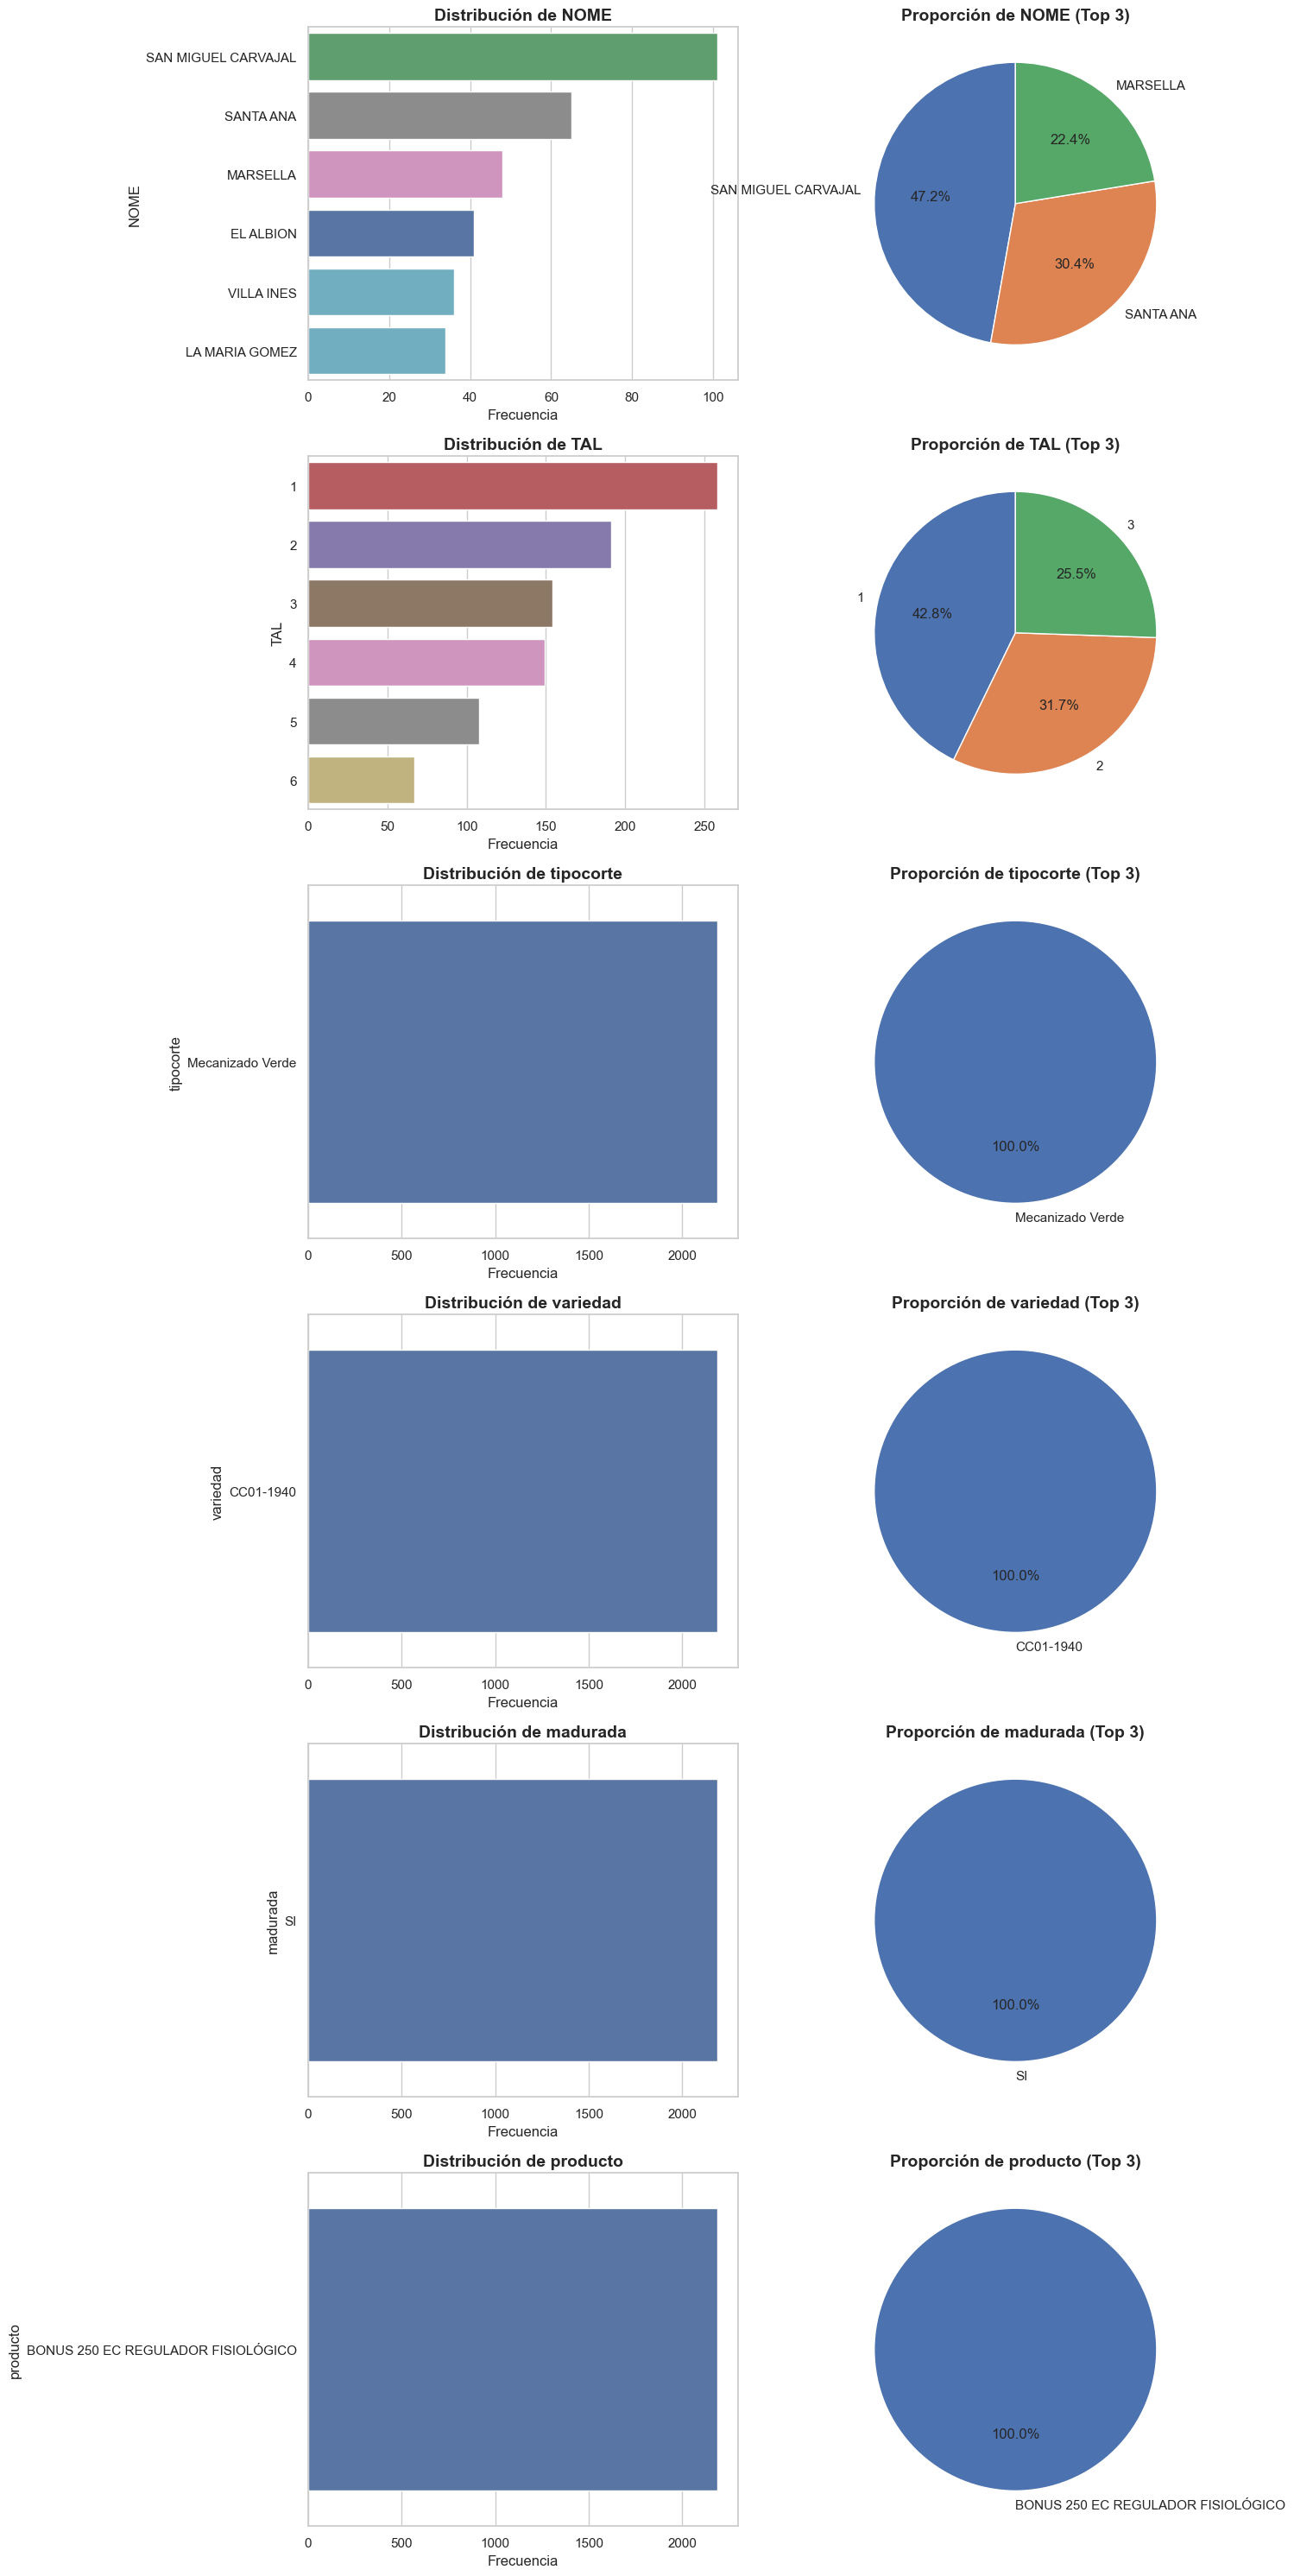

<Figure size 1200x600 with 0 Axes>

In [60]:
def graficos_distribucion_y_torta(categoricas):
    sns.set_theme(style="whitegrid")
    num_vars = len(categoricas.columns)
    fig, axes = plt.subplots(num_vars, 2, figsize=(15, 5 * num_vars))

    if num_vars == 1:
        axes = axes.reshape(1, 2)

    for i, col in enumerate(categoricas.columns):
        freq_abs = categoricas[col].value_counts()

        order = freq_abs.index[:6]  # Top 6 categorías
        sns.countplot(data=categoricas, y=col, order=order,
                      palette="deep", hue=col, legend=False, ax=axes[i, 0])
        axes[i, 0].set_title(f'Distribución de {col}', fontsize=14, fontweight='bold')
        axes[i, 0].set_ylabel(col, fontsize=12)
        axes[i, 0].set_xlabel('Frecuencia', fontsize=12)

        top_categories = freq_abs.head(3)  # Top 3 categorías para torta
        axes[i, 1].pie(top_categories.values, labels=top_categories.index,
                       autopct='%1.1f%%', startangle=90)
        axes[i, 1].set_title(f'Proporción de {col} (Top 3)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
    plt.subplots_adjust(wspace=0.15)  # Ajusta el espacio horizontal entre gráficos
graficos_distribucion_y_torta(categoricas)

##### **Nota:**

Se decide eliminar las variables categoricas 'tipocorte', 'variedad', 'madurada', 'producto' porque no tiene variación en los datos; las 2187 filas corresponden a un mismo valor.Adicional, las variables NOME y TAL se eliminan porque tienen alta cardinalidad, es decir que cuando tiene muchos valores únicos, durante el One-hot encoding se convierten en miles de columnas y esto aumenta el espacio de memoria, ralentiza el entrenamiento y aumenta el riesgo de overfitting.

In [61]:
columnas_a_eliminar = ['tipocorte', 'variedad', 'madurada', 'producto', 'NOME', 'TAL']
df = df.drop(columns=columnas_a_eliminar)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FAZ             2187 non-null   int64  
 1   dosismad        2187 non-null   float64
 2   semsmad         2187 non-null   float64
 3   edad            2187 non-null   float64
 4   cortes          2187 non-null   int64  
 5   me              2187 non-null   float64
 6   vejez           2187 non-null   float64
 7   sacarosa        2187 non-null   float64
 8   mes             2187 non-null   int64  
 9   periodo         2187 non-null   int64  
 10  TCH             2187 non-null   int64  
 11  lluvias         2187 non-null   int64  
 12  grupo_tenencia  2187 non-null   int64  
 13  pct_diatrea     2187 non-null   float64
dtypes: float64(7), int64(7)
memory usage: 239.3 KB


#### **Descriptivas de variables numericas**

In [62]:
numericas.describe()

,FAZ,dosismad,semsmad,edad,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
count,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000,2187.000000
mean,80588.332876,0.993278,9.164838,12.766118,2.794239,9.197759,4.172154,12.777732,6.758573,201887.691358,142.393233,118.051212,2.435299,4.317284
std,572.818299,0.309096,3.441579,1.117866,1.621195,1.574409,6.339255,0.854397,3.482444,131.982686,25.838029,144.424675,0.704058,2.591956
min,80100.000000,0.000000,-1.600000,10.300000,1.000000,3.400000,0.200000,9.200000,1.000000,201407.000000,6.000000,0.000000,1.000000,0.200000
25%,80222.000000,0.800000,7.100000,12.000000,1.000000,8.200000,2.100000,12.200000,4.000000,201807.000000,126.000000,0.000000,2.000000,2.900000
50%,80396.000000,1.000000,8.700000,12.500000,2.000000,9.100000,2.600000,12.800000,7.000000,201908.000000,144.000000,77.000000,3.000000,3.700000
75%,80660.000000,1.200000,10.600000,13.300000,4.000000,10.100000,3.300000,13.300000,10.000000,202005.000000,159.000000,171.500000,3.000000,5.000000
max,82519.000000,9.000000,45.000000,21.100000,14.000000,15.000000,102.900000,16.000000,12.000000,202101.000000,249.000000,1468.000000,3.000000,25.500000


#### **Visualización de boxplots de variables numéricas**

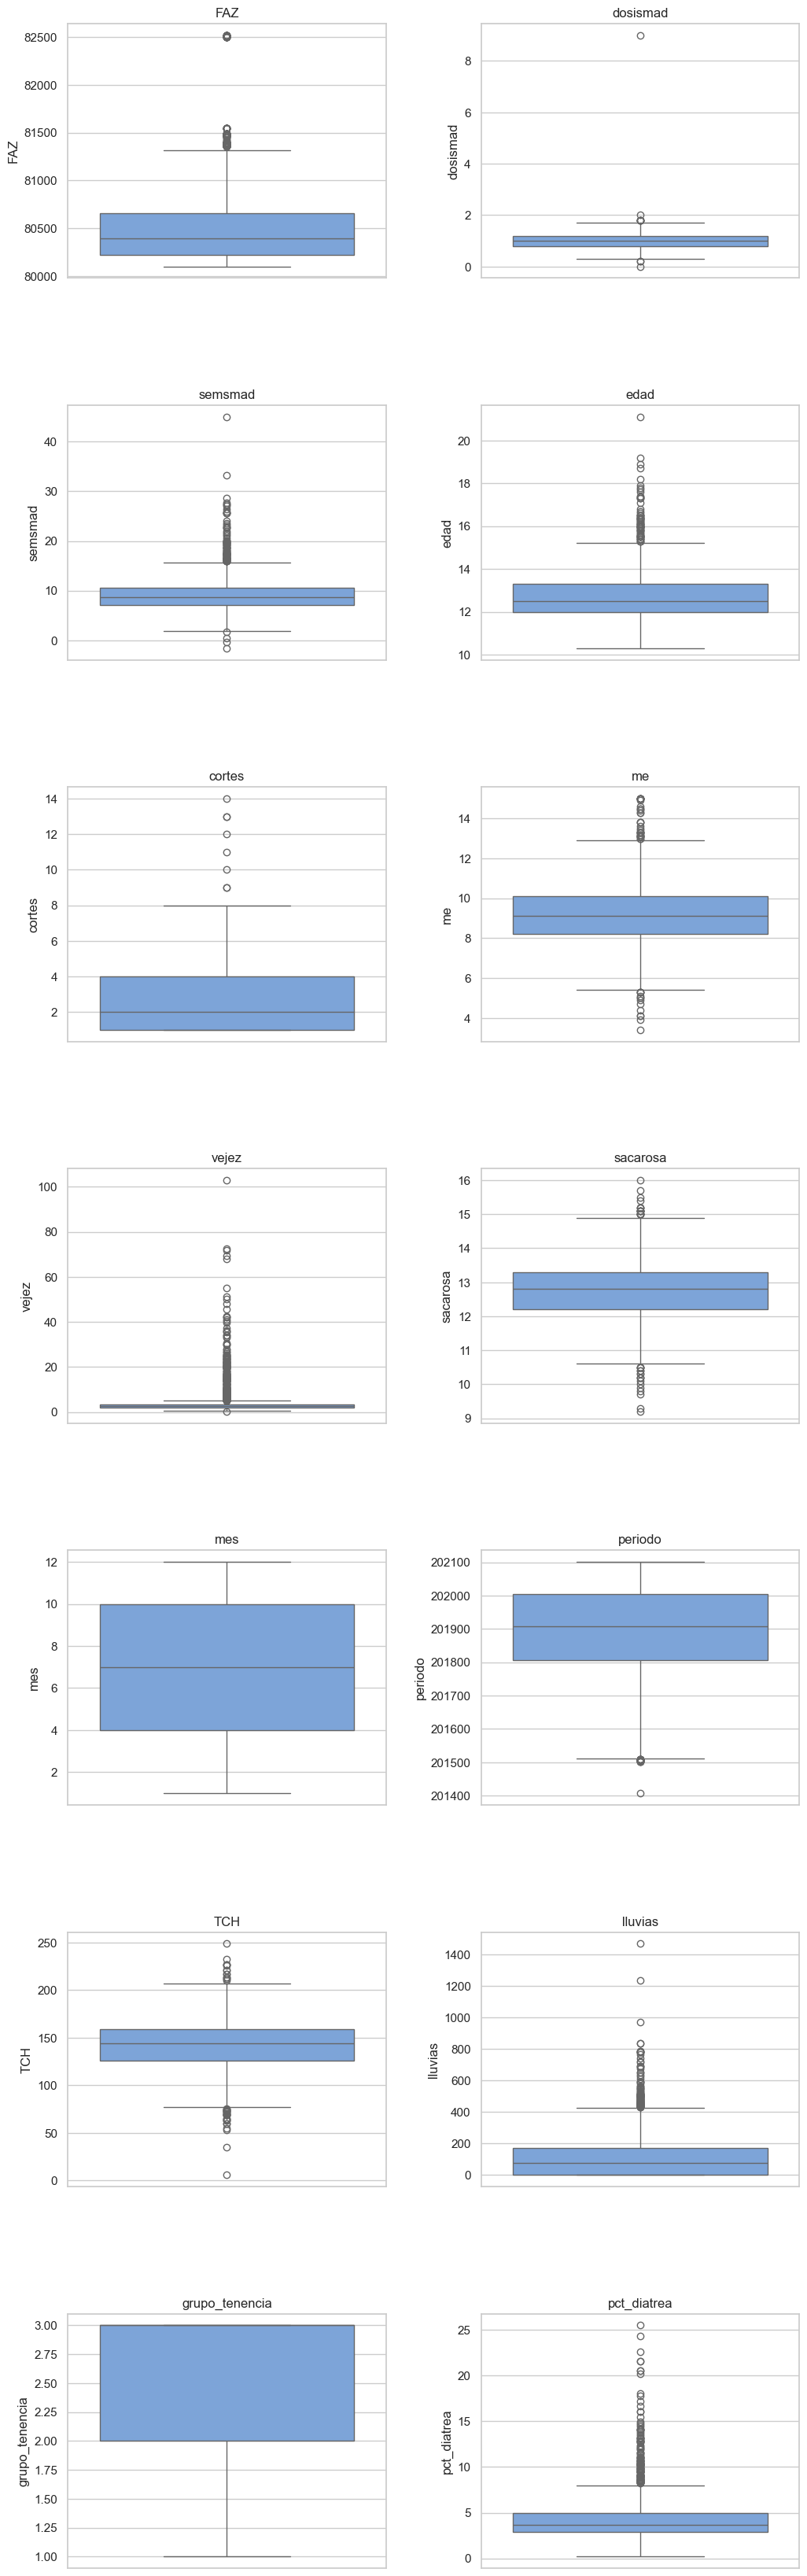

In [63]:
def boxplots_2_por_fila(df):
    # Selecciona solo columnas numéricas int64 o float64
    df_num = df.select_dtypes(include=['int64', 'float64'])
    num_variables = len(df_num.columns)
    columnas = 2
    filas = (num_variables + columnas - 1) // columnas  # 2 columnas por fila

    plt.figure(figsize=(12, filas * 6))

    for i, col in enumerate(df_num.columns):
        plt.subplot(filas, columnas, i + 1)
        sns.boxplot(y=df_num[col], color="#6EA2E7E0")
        plt.title(col)

    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    plt.show()
boxplots_2_por_fila(df)

#### **Limpieza de atipicos en las variables numéricas**

In [64]:
def detectar_y_eliminar_outliers(df, umbral=1.5):
    columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
    resumen = []
    df_limpio = df.copy()

    for col in columnas_numericas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - umbral * IQR
        lim_sup = Q3 + umbral * IQR

        atipicos = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
        total_atipicos = len(atipicos)
        porcentaje = round((total_atipicos / len(df)) * 100, 2)
        resumen.append({
            'columna': col,
            'total_atipicos': total_atipicos,
            'porcentaje_atipicos': porcentaje,
            'limite_inferior': lim_inf,
            'limite_superior': lim_sup,
            'minimo': df[col].min(),
            'maximo': df[col].max()
        })

        df_limpio = df_limpio[(df_limpio[col] >= lim_inf) & (df_limpio[col] <= lim_sup)]

    resumen_df = pd.DataFrame(resumen)
    indices_sin_outliers = df_limpio.index

    # Filtrar el DataFrame original con esos índices para asegurar consistencia
    df_filtrado = df.loc[indices_sin_outliers].copy()

    return df_filtrado, resumen_df

# Uso ejemplo con df original
df_limpio, resumen_outliers = detectar_y_eliminar_outliers(df)

# Mostrar resumen
display(resumen_outliers)

print("="*60)

# Revisar dimensiones y primeras filas del DataFrame limpio
print("Dimensiones del DataFrame limpio:", df_limpio.shape)
display(df_limpio.head(5))

,columna,total_atipicos,porcentaje_atipicos,limite_inferior,limite_superior,minimo,maximo
0,FAZ,250,11.43,79565.00,81317.00,80100.0,82519.0
1,dosismad,11,0.50,0.20,1.80,0.0,9.0
2,semsmad,92,4.21,1.85,15.85,-1.6,45.0
3,edad,70,3.20,10.05,15.25,10.3,21.1
4,cortes,8,0.37,-3.50,8.50,1.0,14.0
5,me,49,2.24,5.35,12.95,3.4,15.0
6,vejez,268,12.25,0.30,5.10,0.2,102.9
7,sacarosa,37,1.69,10.55,14.95,9.2,16.0
8,mes,0,0.00,-5.00,19.00,1.0,12.0
9,periodo,20,0.91,201510.00,202302.00,201407.0,202101.0


Dimensiones del DataFrame limpio: (1359, 14)


,FAZ,dosismad,semsmad,edad,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
0,81291,0.8,8.3,12.3,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,81291,0.8,6.3,11.2,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,81291,0.6,7.9,12.2,3,8.8,1.8,13.3,3,202003,167,68,3,4.3
3,81291,0.8,6.6,13.1,1,6.1,2.5,13.4,3,201903,156,0,3,3.5
4,81291,0.6,8.1,12.2,2,7.9,2.1,14.0,3,202003,151,68,3,4.3


#### **Por medio de Histogramas y boxplots se visualiza la distribución de cada variable númerica, después de eliminar atipicos**

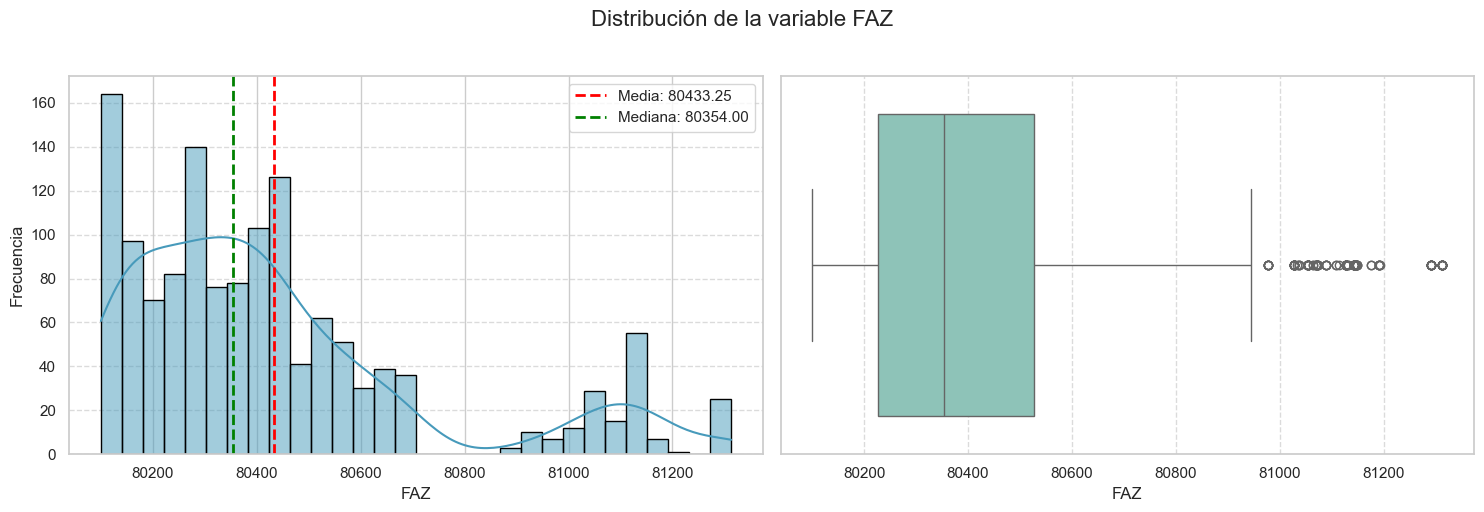

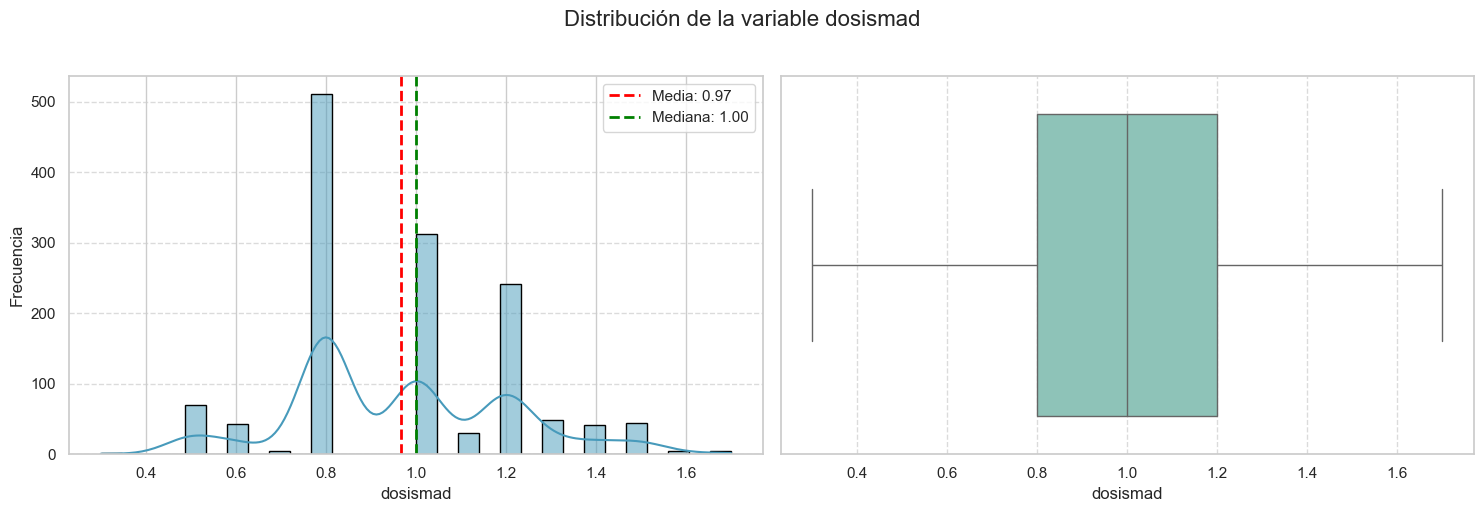

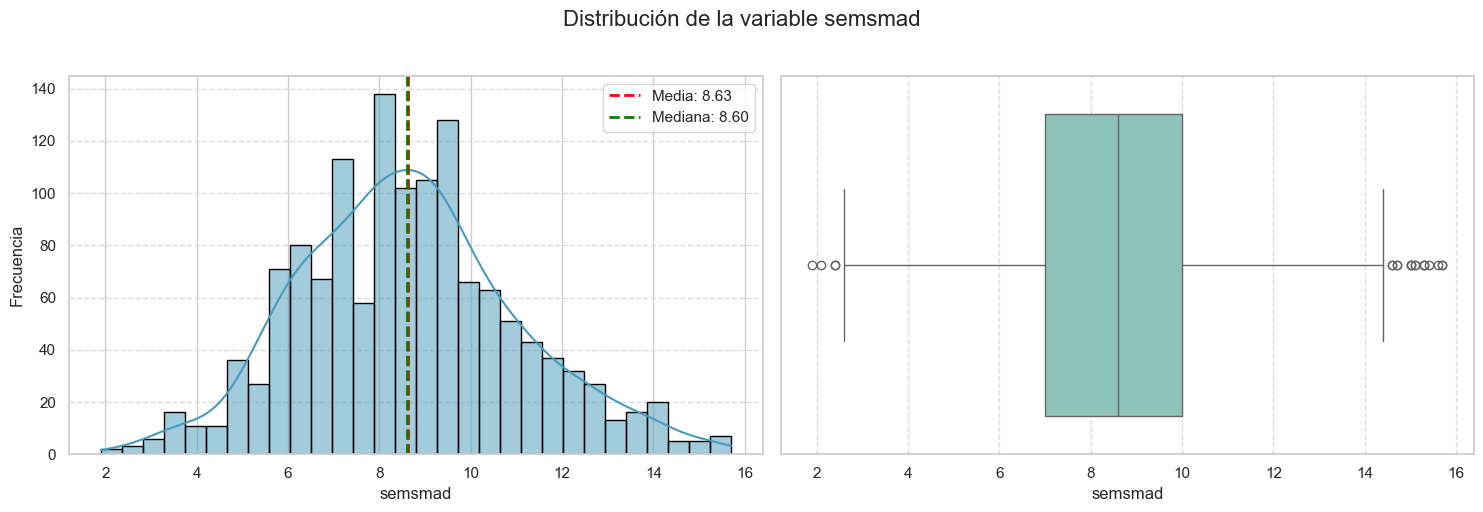

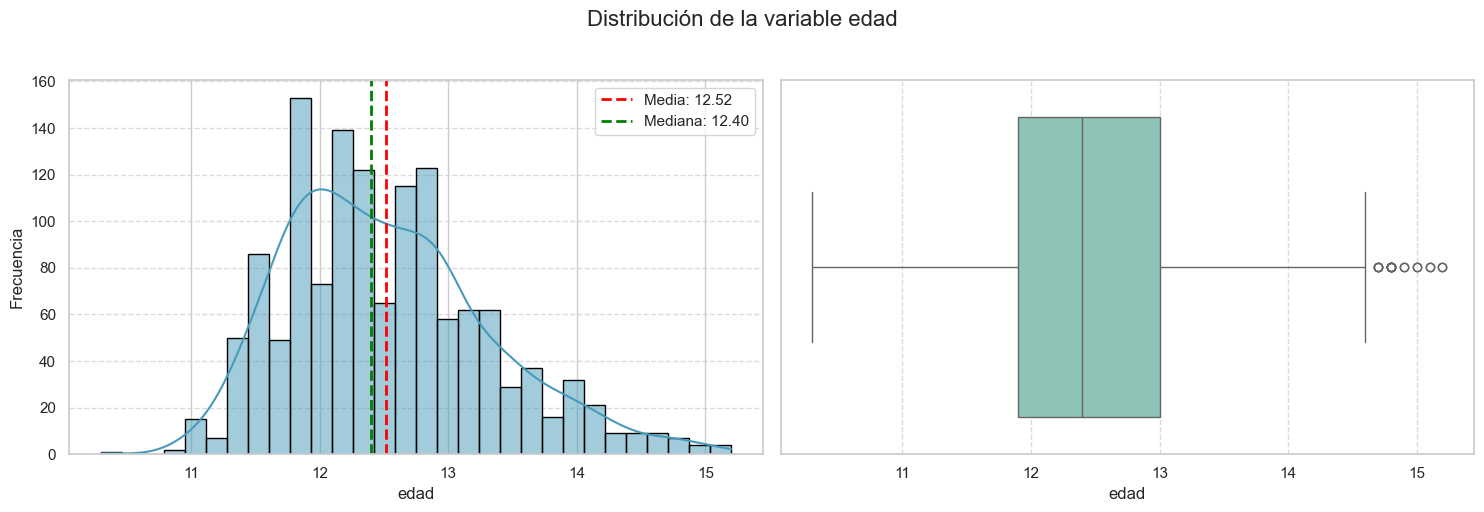

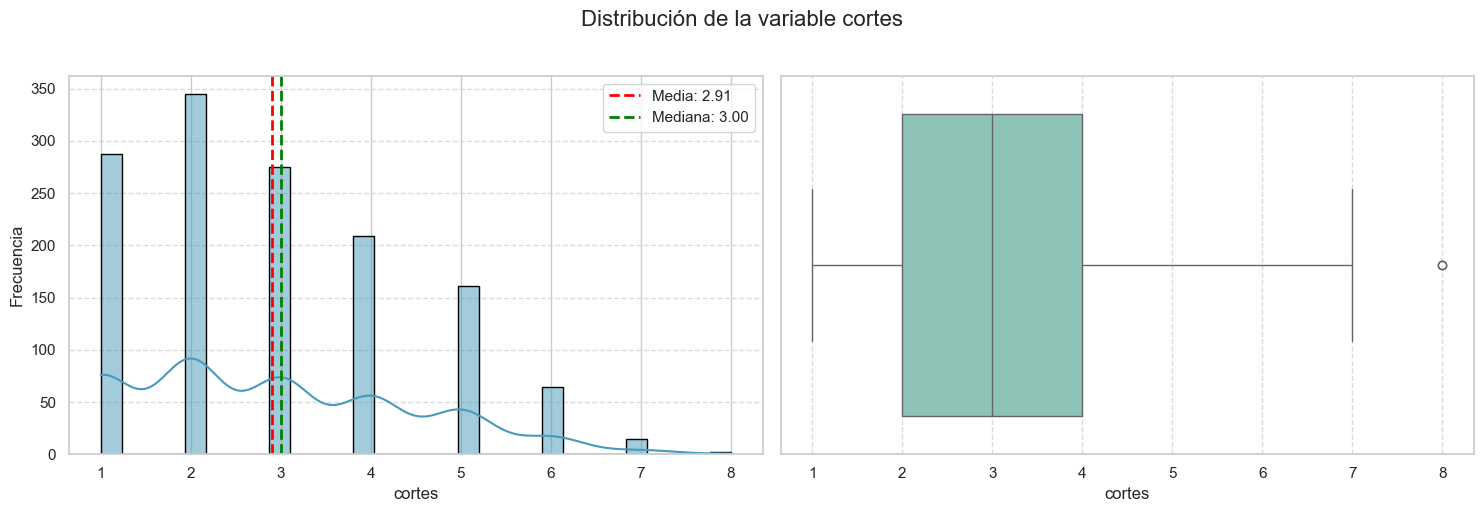

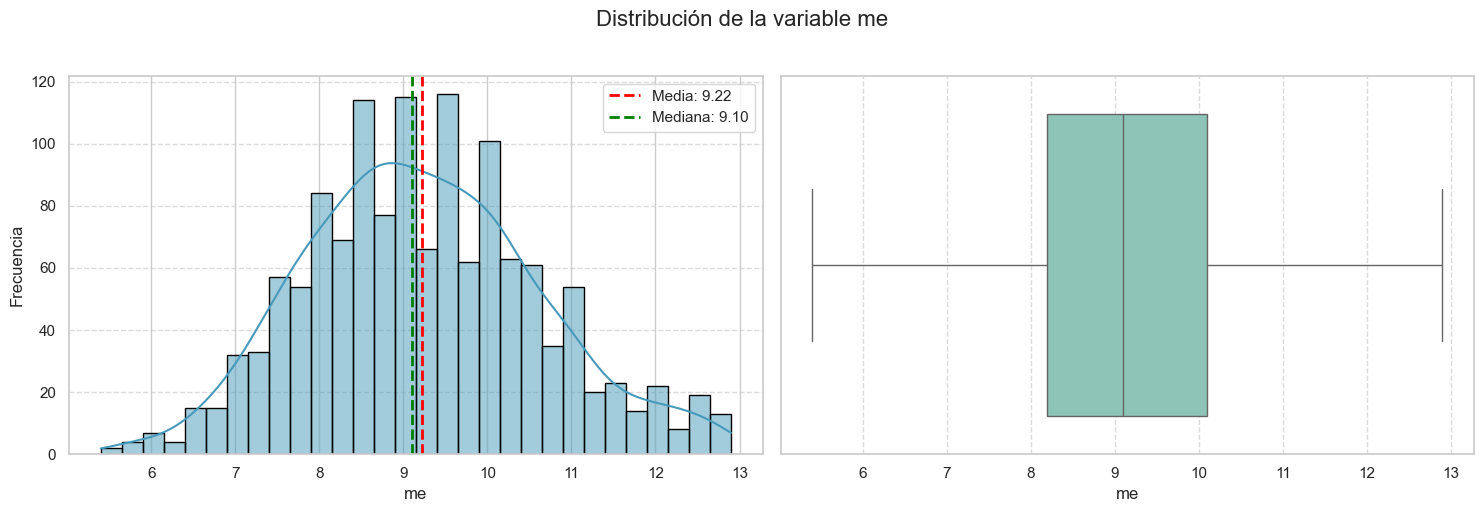

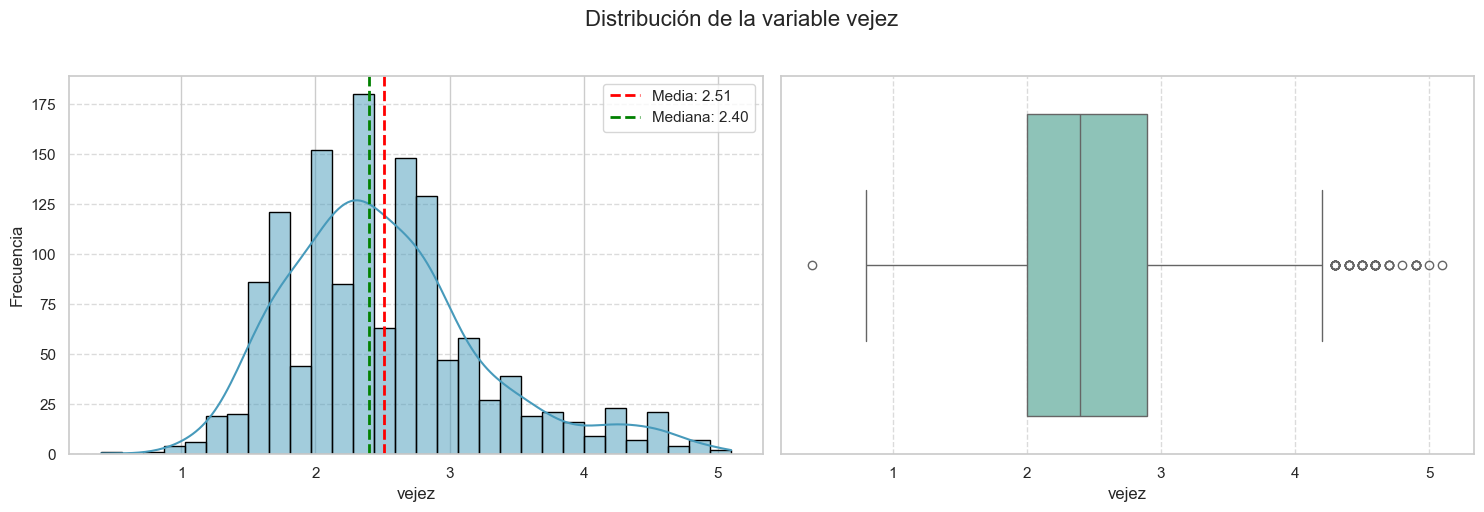

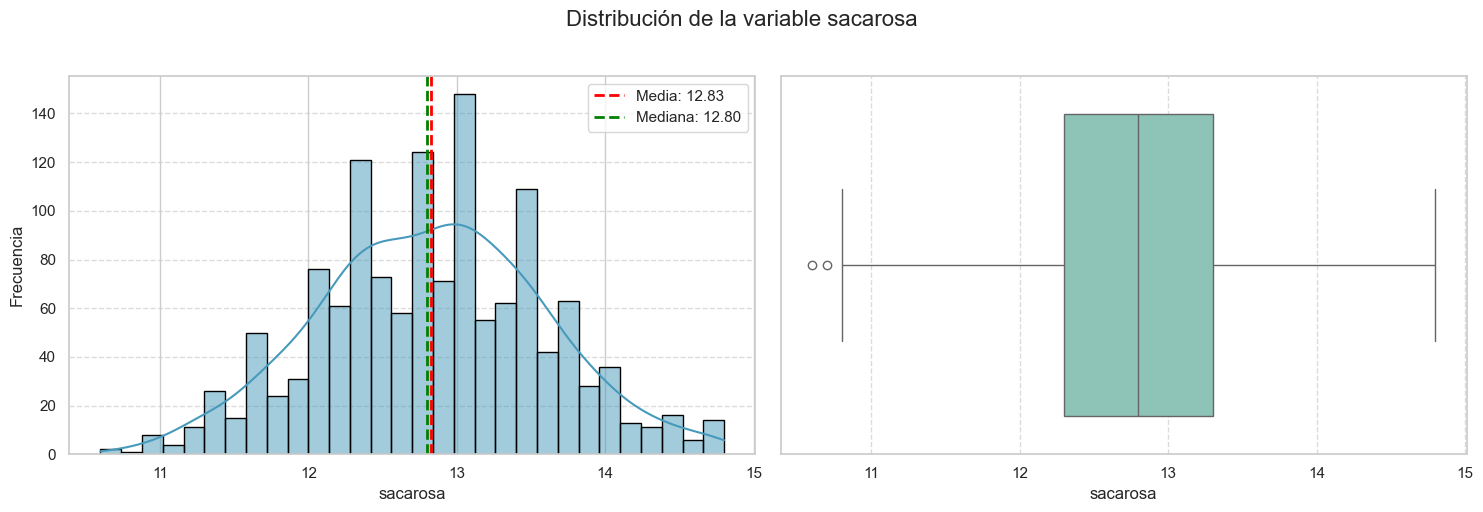

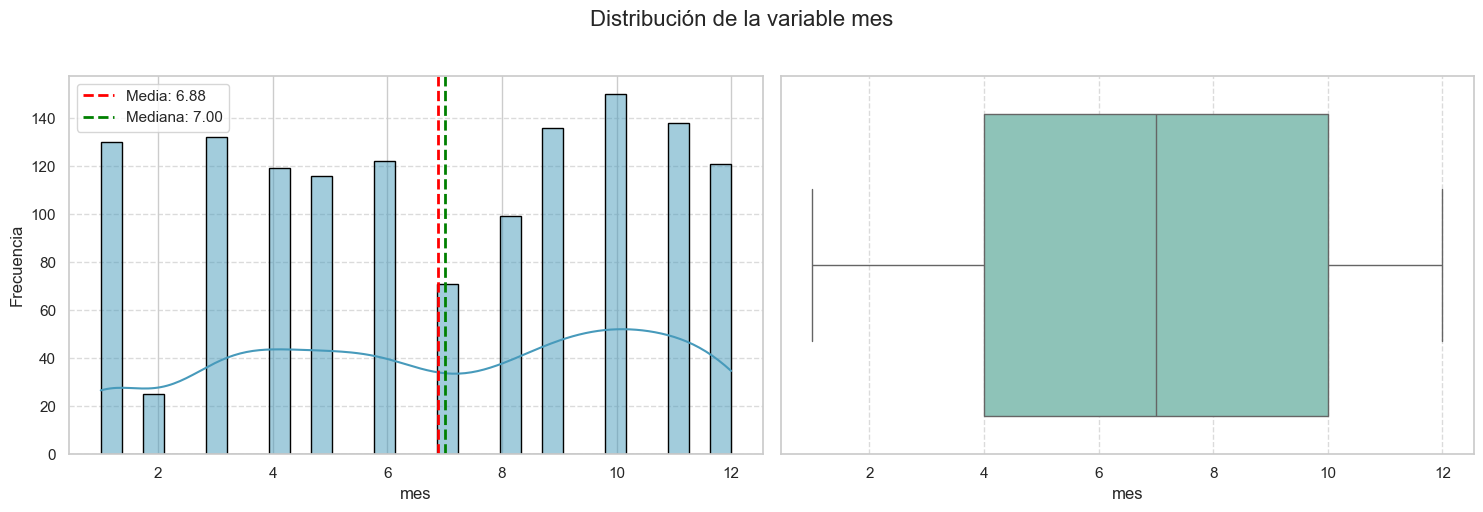

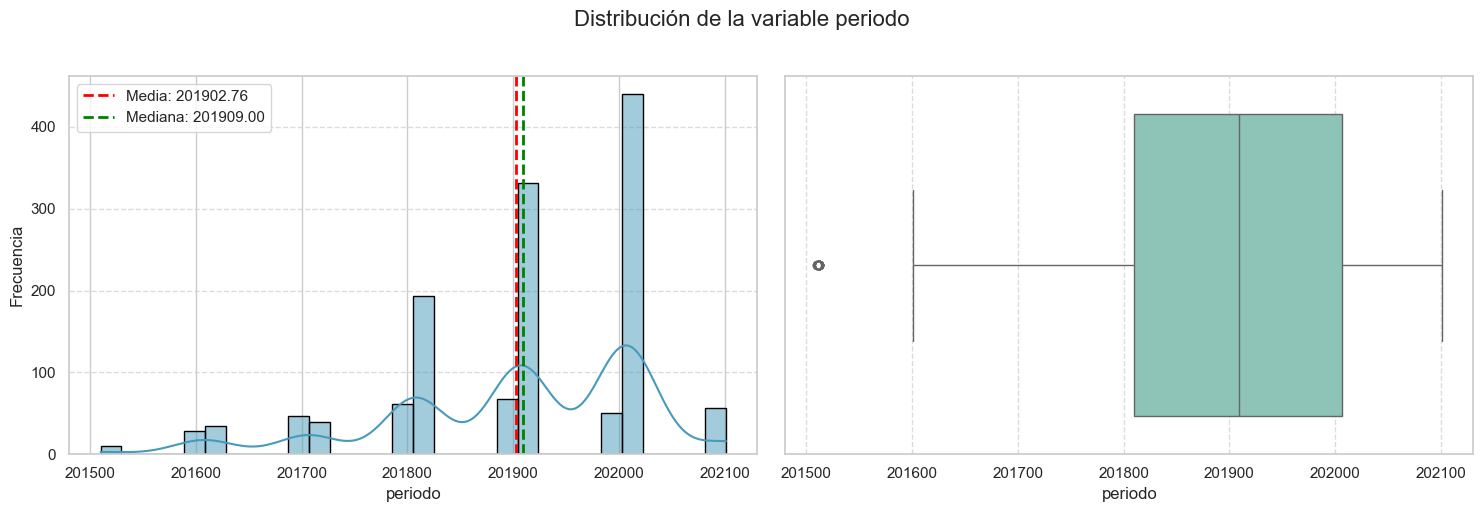

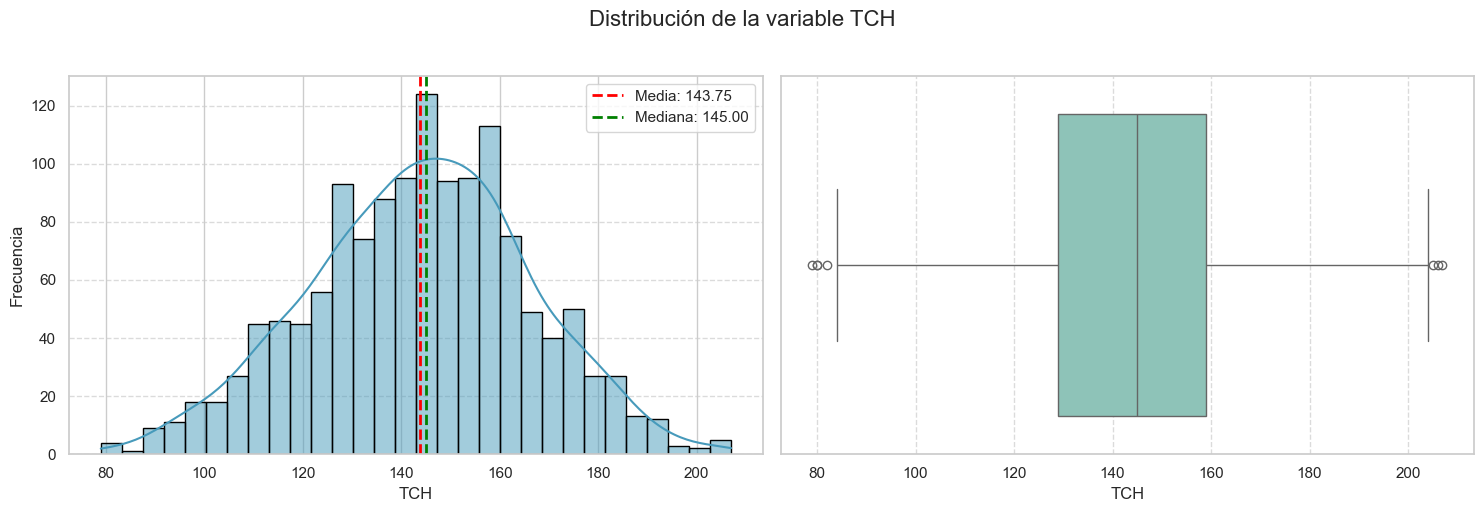

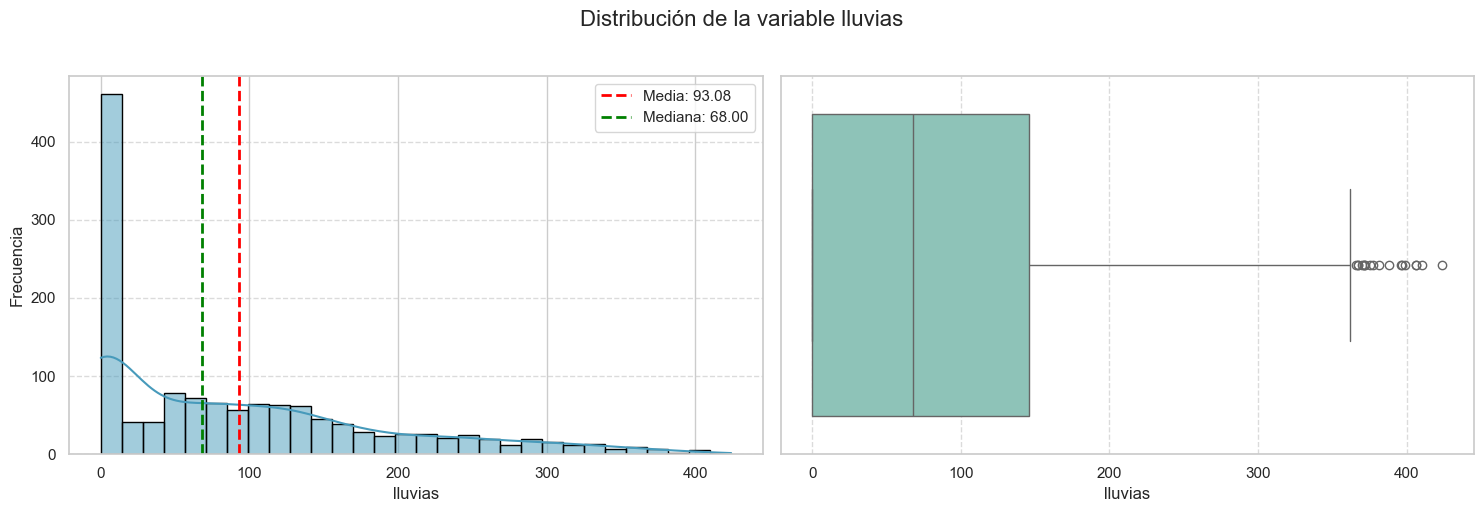

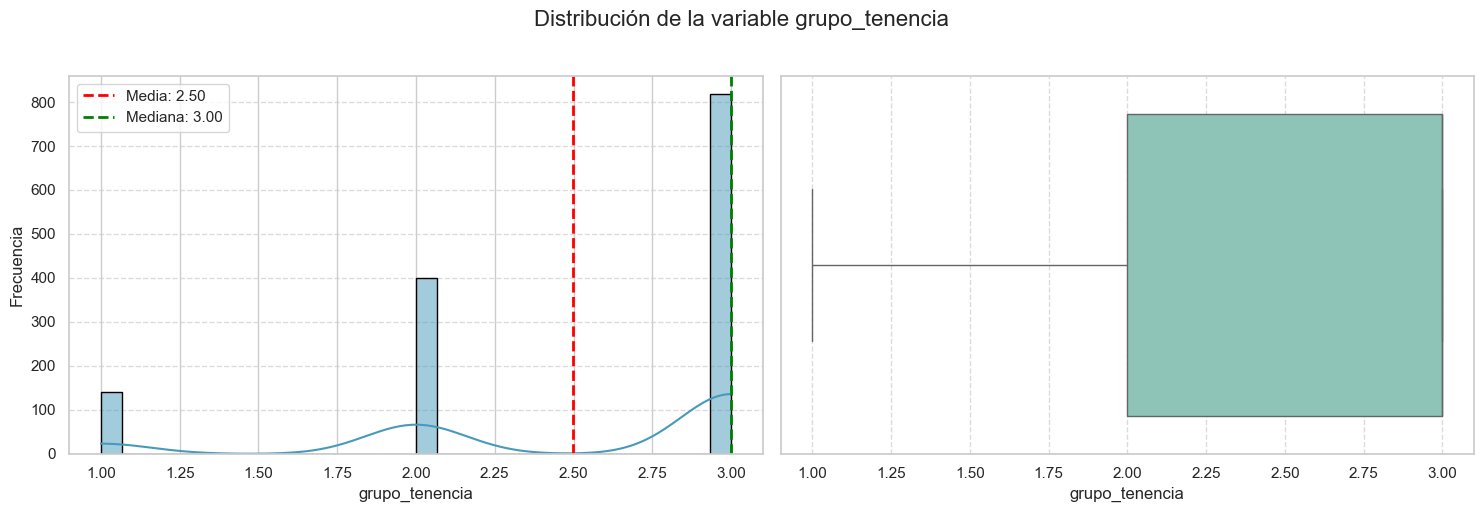

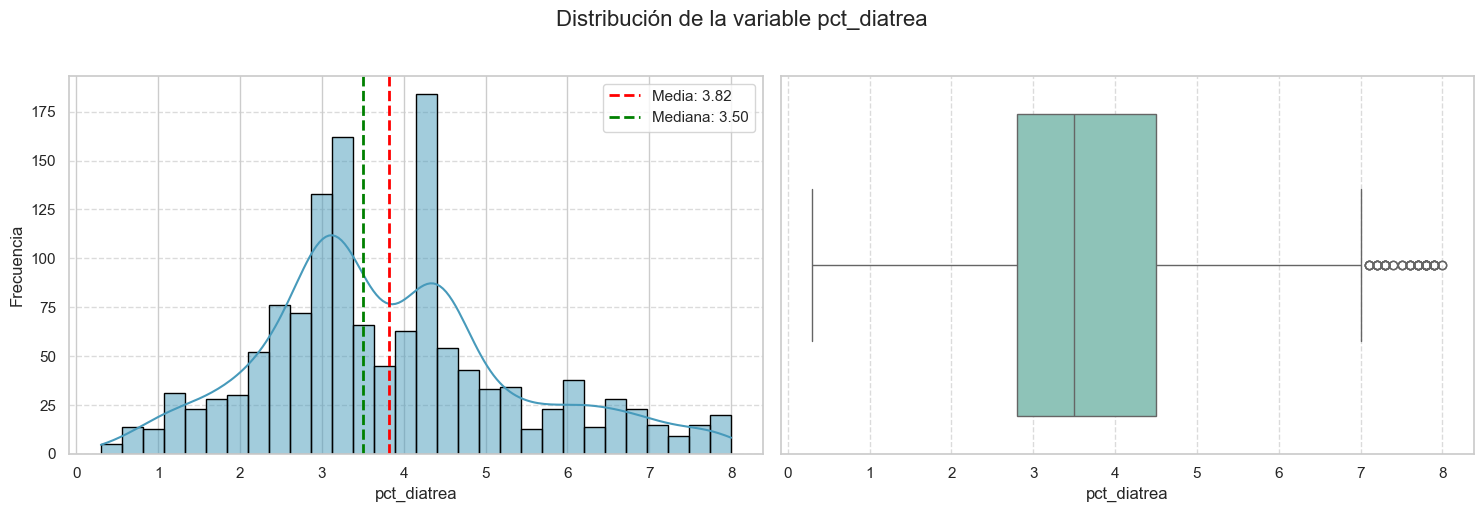

In [65]:
for col in df_limpio.columns:
    # Verificar que la columna sea numérica para poder graficar y calcular estadísticas
    if pd.api.types.is_numeric_dtype(df_limpio[col]):
        # Omitir valores NaN para los cálculos y gráficos
        data = df_limpio[col].dropna()

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        plt.suptitle(f'Distribución de la variable {col}', fontsize=16, y=1.02)

        # Histograma con seaborn
        sns.histplot(data, bins=30, kde=True, color="#479ABB", edgecolor='black', ax=ax1)
        ax1.set_xlabel(col)
        ax1.set_ylabel('Frecuencia')
        ax1.grid(axis='y', linestyle='--', alpha=0.7)

        # Medidas de tendencia central
        media = data.mean()
        mediana = data.median()

        # Líneas verticales para las medidas centrales
        ax1.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media:.2f}')
        ax1.axvline(mediana, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana:.2f}')
        ax1.legend()

        # Boxplot horizontal
        sns.boxplot(x=data, color="#85CCBD", ax=ax2)
        ax2.set_xlabel(col)
        ax2.grid(axis='x', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()


### **Análisis Multivariado**

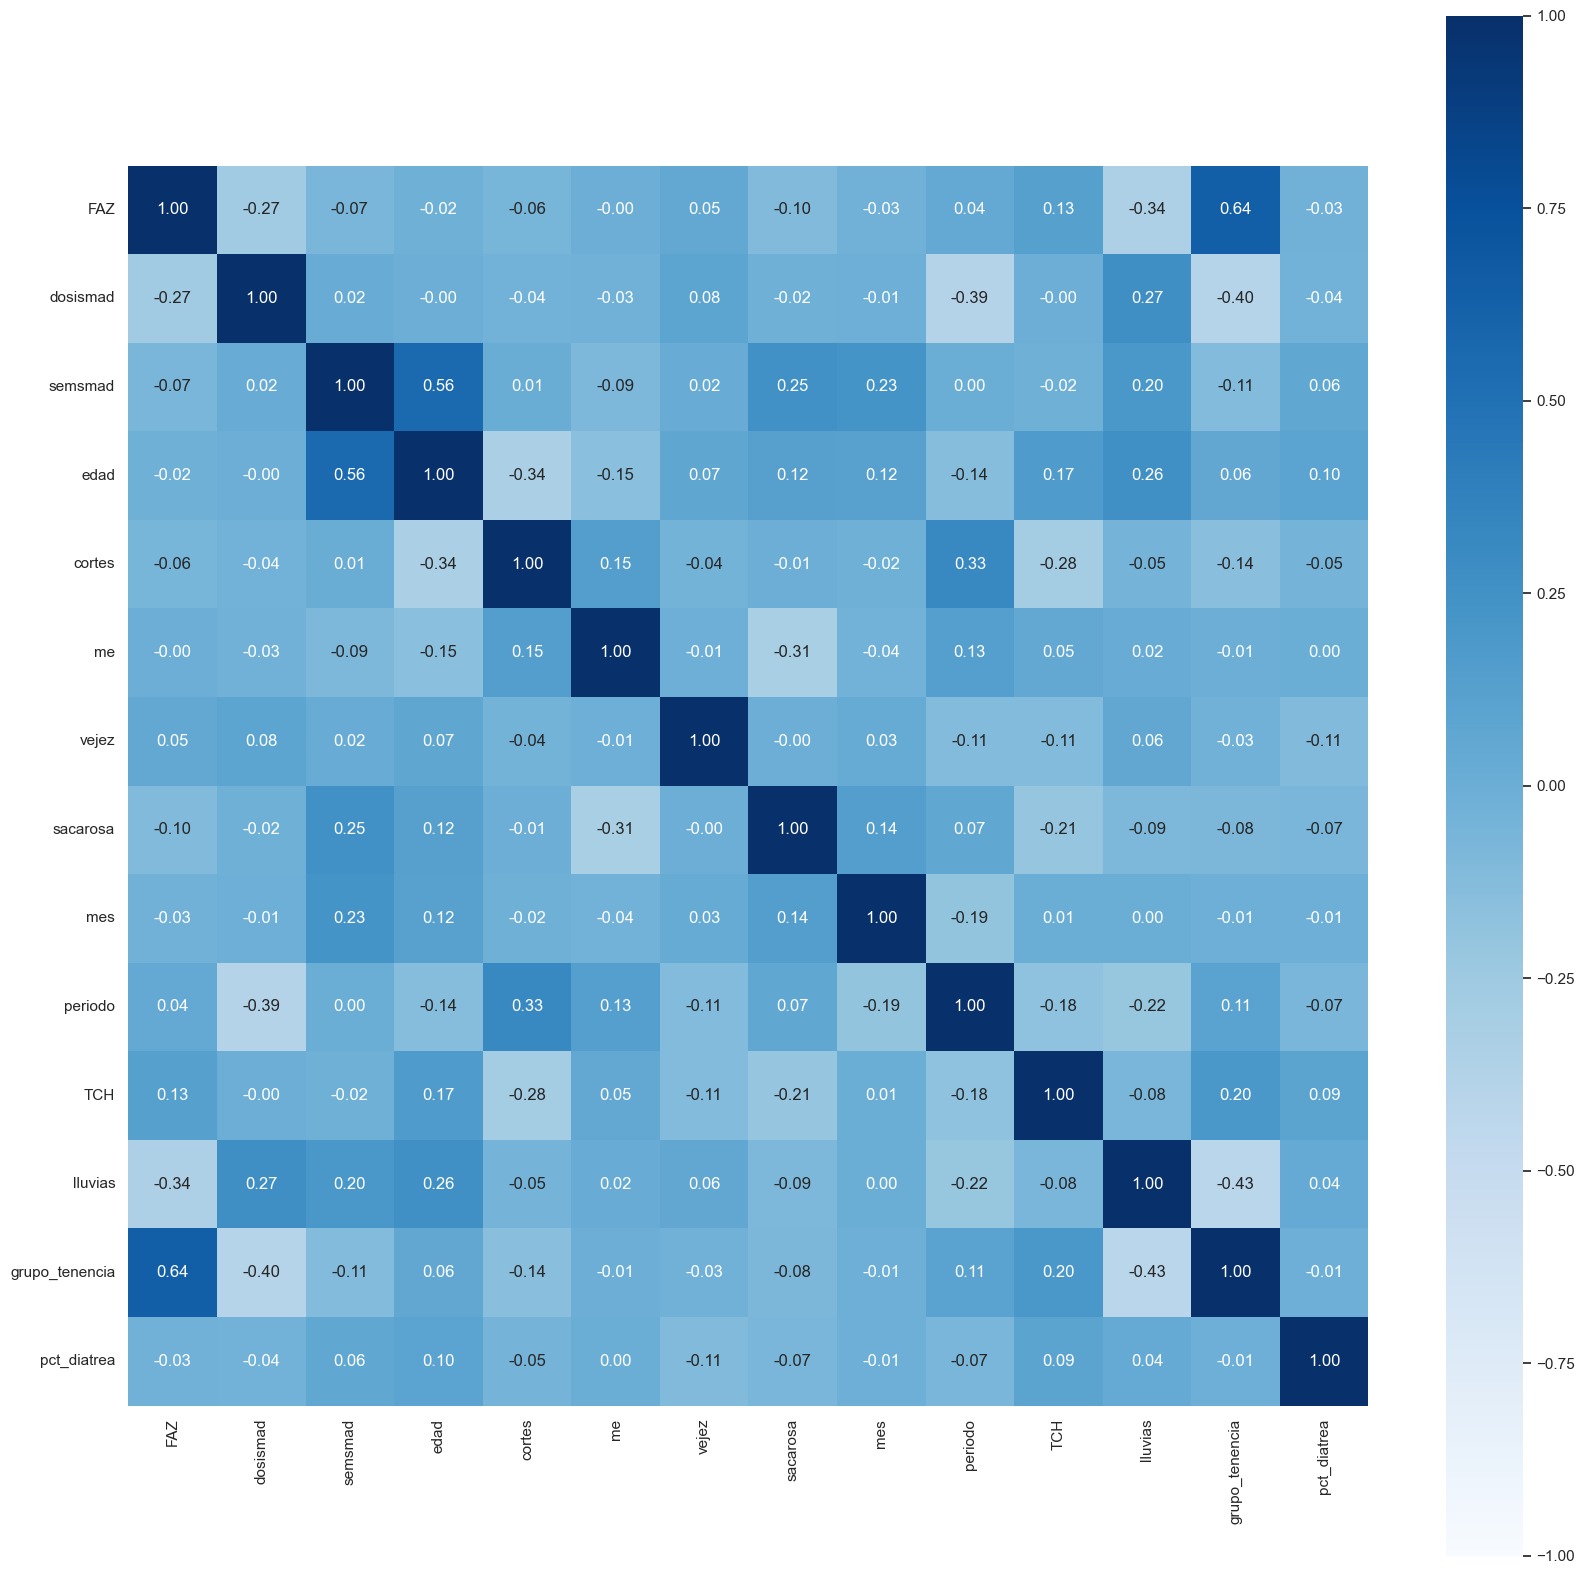

In [66]:
Mapa_correlacion= associations(df_limpio, filename= 'Mapa_correlacion.png', figsize=(20,20), cmap="Blues")

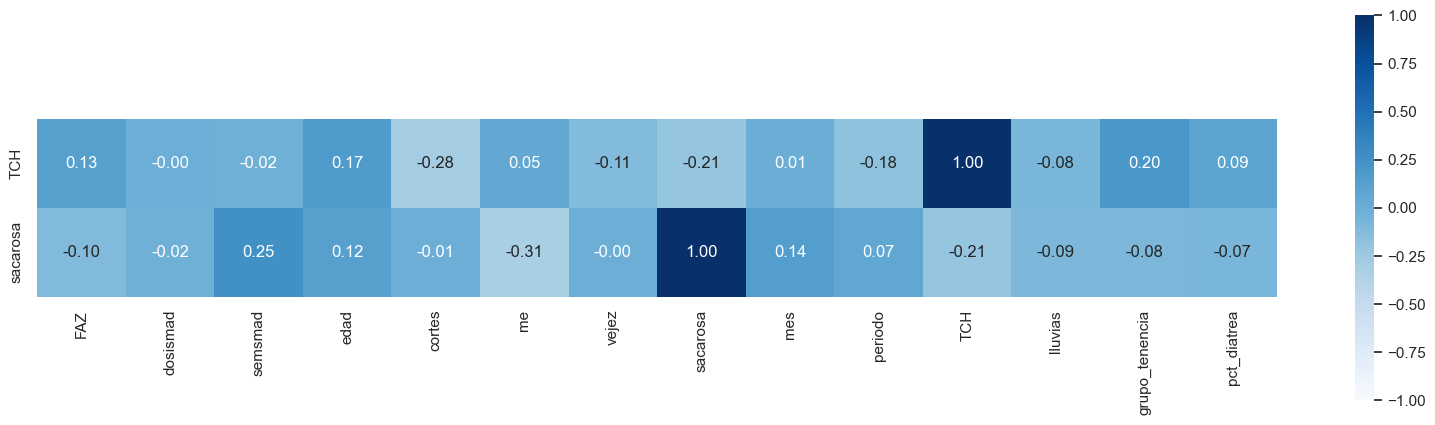

In [67]:
target_correlation_dict = associations(df_limpio, display_rows=['TCH', 'sacarosa'], filename='target_correlation.png', figsize=(20,5), cmap='Blues')

matriz_correlacion = target_correlation_dict['corr']

# Variables objetivo
objetivos = ['TCH', 'sacarosa']

# Seleccionar solo las filas de las variables objetivo
correlaciones_variables_objetivos = matriz_correlacion.loc[objetivos]

# Eliminar la correlación de las variables objetivo consigo mismas
correlaciones_variables_objetivos = matriz_correlacion.loc[objetivos]
correlaciones_variables_objetivos = correlaciones_variables_objetivos.drop(columns=objetivos)  # Solo columnas, no filas

## **Creación de nuevas Categorías:**
Definir umbrales para transformar las variables continuas TCH y %Sac.Caña en categorías: alto, medio y bajo. Justificar la metodología empleada para definir estos cortes (por ejemplo, percentiles, criterios de negocio, etc.).

In [68]:
# Metodología para definir umbrales: Percentiles
# Usamos los percentiles 33 y 66 para dividir los datos en tres grupos aproximadamente iguales (bajo, medio, alto).
# Esta es una estrategia común cuando no existen criterios de negocio predefinidos.

# Definir umbrales usando percentiles para TCH
umbral_bajo_tch = df_limpio['TCH'].quantile(0.33)
umbral_medio_alto_tch = df_limpio['TCH'].quantile(0.66)

# Crear la nueva columna 'TCH_categoria'
def clasificacion_tch(tch):
    if tch <= umbral_bajo_tch:
        return 'bajo'
    elif tch <= umbral_medio_alto_tch:
        return 'medio'
    else:
        return 'alto'

df_limpio['TCH_categoria'] = df_limpio['TCH'].apply(clasificacion_tch)

# Definir umbrales usando percentiles para %Sac.Caña
umbral_bajo_sac = df_limpio['sacarosa'].quantile(0.33)
umbral_medio_alto_sac = df_limpio['sacarosa'].quantile(0.66)

# Crear la nueva columna 'Sac_categoria'
def clasificacion_sac(sac):
    if sac <= umbral_bajo_sac:
        return 'bajo'
    elif sac <= umbral_medio_alto_sac:
        return 'medio'
    else:
        return 'alto'

df_limpio['Sac_categoria'] = df_limpio['sacarosa'].apply(clasificacion_sac)

# Mostrar las primeras filas con las nuevas categorías
display(df_limpio[['TCH', 'TCH_categoria', 'sacarosa', 'Sac_categoria']].head())

# Mostrar la distribución de las nuevas categorías con conteo y porcentaje

import pandas as pd

# Para TCH_categoria
tch_counts = df_limpio['TCH_categoria'].value_counts()
tch_percent = df_limpio['TCH_categoria'].value_counts(normalize=True) * 100
tch_distribution = pd.DataFrame({
    'Conteo': tch_counts,
    'Porcentaje (%)': tch_percent.round(2)
})

print("\nDistribución de la categoría TCH:")
display(tch_distribution)

# Para Sac_categoria
sac_counts = df_limpio['Sac_categoria'].value_counts()
sac_percent = df_limpio['Sac_categoria'].value_counts(normalize=True) * 100
sac_distribution = pd.DataFrame({
    'Conteo': sac_counts,
    'Porcentaje (%)': sac_percent.round(2)
})

print("\nDistribución de la categoría %Sac.Caña:")
display(sac_distribution)


,TCH,TCH_categoria,sacarosa,Sac_categoria
0,112,bajo,14.0,alto
1,157,alto,13.0,medio
2,167,alto,13.3,alto
3,156,alto,13.4,alto
4,151,medio,14.0,alto



Distribución de la categoría TCH:


,Conteo,Porcentaje (%)
TCH_categoria,,
bajo,465,34.22
alto,460,33.85
medio,434,31.94



Distribución de la categoría %Sac.Caña:


,Conteo,Porcentaje (%)
Sac_categoria,,
bajo,503,37.01
alto,455,33.48
medio,401,29.51



#### **Visualización de las nuevas Categorías:**


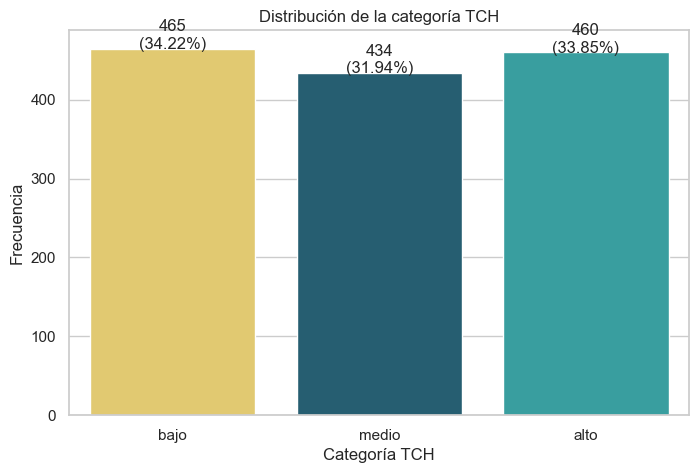

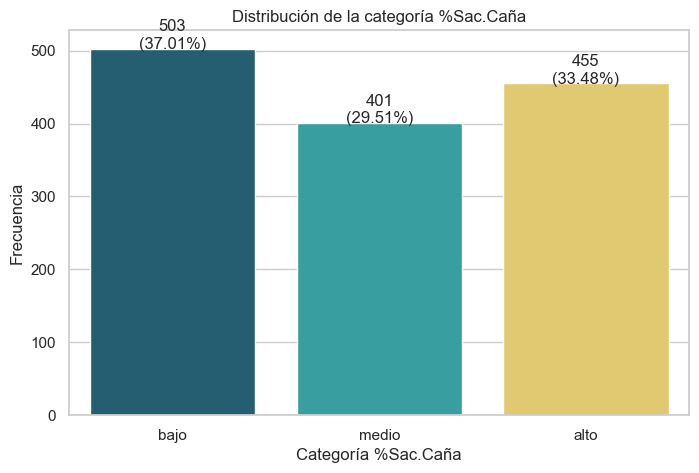

In [69]:
colores = ["#F4D35E", "#28AFB0", "#19647E"]

# Gráfico para TCH_categoria
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='TCH_categoria', hue='TCH_categoria', data=df_limpio,
                   order=['bajo', 'medio', 'alto'], palette=colores, legend=False)
plt.title('Distribución de la categoría TCH')
plt.xlabel('Categoría TCH')
plt.ylabel('Frecuencia')

total = len(df_limpio)
for p in ax.patches:
    altura = p.get_height()
    porcentaje = (altura / total) * 100
    ax.text(p.get_x() + p.get_width() / 2., altura + 0.1,
            f"{int(altura)}\n({porcentaje:.2f}%)", ha="center")

plt.show()

# Gráfico para Sac_categoria
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Sac_categoria', hue='Sac_categoria', data=df_limpio,
                   order=['bajo', 'medio', 'alto'], palette=colores, legend=False)
plt.title('Distribución de la categoría %Sac.Caña')
plt.xlabel('Categoría %Sac.Caña')
plt.ylabel('Frecuencia')

total = len(df_limpio)
for p in ax.patches:
    altura = p.get_height()
    porcentaje = (altura / total) * 100
    ax.text(p.get_x() + p.get_width() / 2., altura + 0.1,
            f"{int(altura)}\n({porcentaje:.2f}%)", ha="center")

#for p in ax.patches: ESTO es solo para label de conteo
# altura = p.get_height()
# ax.text(p.get_x() + p.get_width() / 2., altura + 0.1, int(altura), ha="center")

plt.show()




In [70]:
df_limpio.dtypes

FAZ                 int64
dosismad          float64
semsmad           float64
edad              float64
cortes              int64
me                float64
vejez             float64
sacarosa          float64
mes                 int64
periodo             int64
TCH                 int64
lluvias             int64
grupo_tenencia      int64
pct_diatrea       float64
TCH_categoria      object
Sac_categoria      object
dtype: object

## **Desarrollo de Modelos de Clasificación:**

Ajustar un modelo de regresión logística y/o aplicar el algoritmo K-Nearest Neighbors (KNN) para clasificar las observaciones según los niveles definidos.


* **Nota:** Se excluyen las variables TCH_categoria, Sac_categoria, sacarosa y TCH de las variables predictoras para evitar usar las variables objetivos o altamente relacionadas.

### **Variable objetivo TCH**

#### **Regresión logística sin regularización**

In [71]:
# Definición de variable dependientes e independiente.
X = df_limpio.drop(columns=['sacarosa', 'TCH','TCH_categoria', 'Sac_categoria'])
y = df_limpio["TCH_categoria"]


# Division conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#Dimensiones del dataframe
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (951, 12)
Dimensiones de X_test: (408, 12)
Dimensiones de y_train: (951,)
Dimensiones de y_test: (408,)


* **Nota:**
A continuación, se identifican y seleccionan las variables numericas y categoricas del dataset. Posteriormente, se configura el pipeline para aplicar StandardScaler a las columnas numéricas y OneHotEncoder a las categóricas. Esto con el fin, de que el procesamiento sea reproducible y adecuado para la regresión logística.

In [72]:
# Identificación de columnas numéricas y categóricas
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


#Crear preprocesador con ColumnTransformer usando Pipeline
preprocessor = ColumnTransformer([("num", StandardScaler(), num_cols),("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown='ignore'), cat_cols)])

print("Preprocesador para TCH configurado.")

Preprocesador para TCH configurado.


In [73]:
# Pipeline para regresión logística
pipeline = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(solver='liblinear', max_iter=1000))])


# Entrenar modelo
softmax_model = pipeline.fit(X_train, y_train)

print("Modelo de Regresión Logística para TCH entrenado exitosamente.")
display(pipeline)

Modelo de Regresión Logística para TCH entrenado exitosamente.


c:\Users\mafab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Reporte de clasificación:
              precision    recall  f1-score   support

        alto       0.53      0.68      0.59       138
        bajo       0.47      0.59      0.52       140
       medio       0.34      0.14      0.20       130

    accuracy                           0.48       408
   macro avg       0.45      0.47      0.44       408
weighted avg       0.45      0.48      0.44       408

Exactitud: 0.47794117647058826
Matriz de Confusión:
[[94 26 18]
 [40 83 17]
 [44 68 18]]


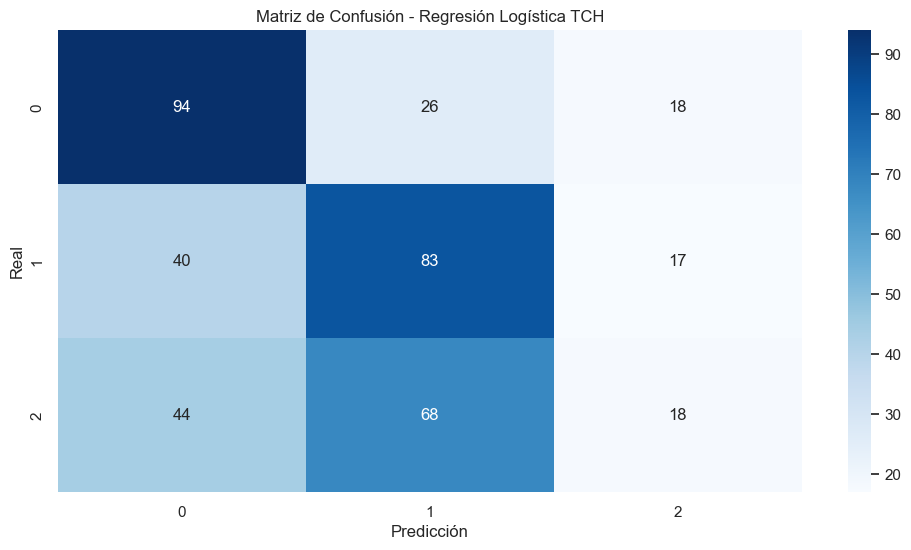

In [74]:
# Predecir
y_pred = softmax_model.predict(X_test)

# Evaluar
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

print("="*40)

print("Exactitud:", accuracy_score(y_test, y_pred))

print("="*40)

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(cm)

print("="*40)

# Visualización gráfica
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Regresión Logística TCH')
plt.show()

* **Nota:**
Para entender a qué categoría corresponde cada número (0, 1, 2) en la matriz de confusión, debemos referirnos al orden de las clases que el modelo aprendió durante el entrenamiento. Este orden se visualiza en la siguiente linea de código

In [75]:
# Mostrar el orden de las clases aprendidas por el modelo para TCH
print(softmax_model.classes_)

['alto' 'bajo' 'medio']


* **Interpretación:**

De acuerdo con lo anterior, la matriz de confusión es:

*   La etiqueta **0** corresponde a la categoría **'alto'**.
*   La etiqueta **1** corresponde a la categoría **'bajo'**.
*   La etiqueta **2** corresponde a la categoría **'medio'**.

Probabilidades por clase para la primera muestra de test:
 [0.34682694 0.32291612 0.33025693]


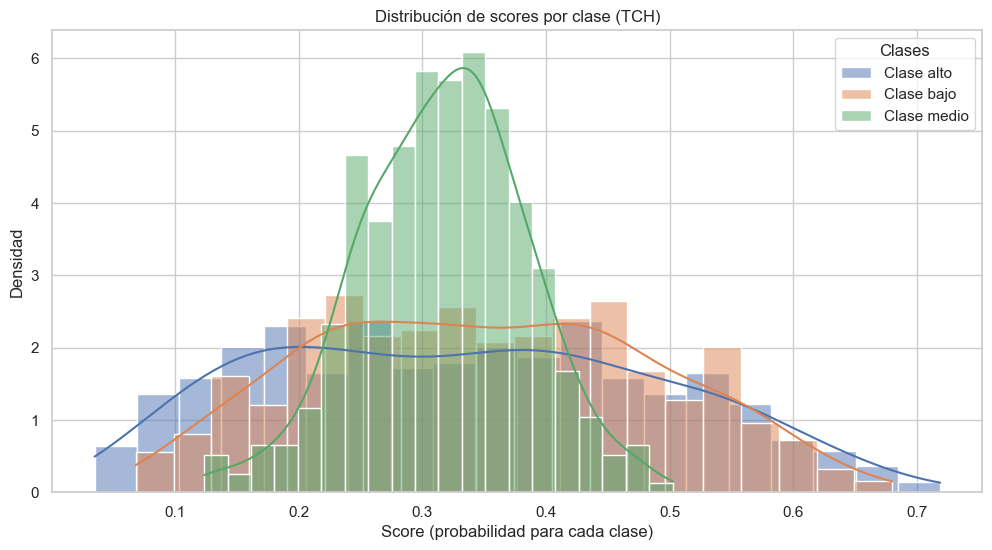

In [76]:
# Obtener probabilidades de pertenecer a cada clase
y_prob = softmax_model.predict_proba(X_test)

# Visualizar probabilidades de la primera muestra como ejemplo
print("Probabilidades por clase para la primera muestra de test:\n", y_prob[0])

print("="*40)

# Visualización tipo histograma/kde para los scores de cada clase
plt.figure(figsize=(12, 6))
for idx, clase in enumerate(pipeline.named_steps['clf'].classes_):
    scores_clase = y_prob[:, idx]
    sns.histplot(scores_clase, kde=True, bins=20, label=f'Clase {clase}', stat='density')

plt.xlabel("Score (probabilidad para cada clase)")
plt.ylabel("Densidad")
plt.legend(title="Clases")
plt.title("Distribución de scores por clase (TCH)")
plt.show()

In [77]:
# Aplicar el preprocesador a los datos de entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Identificar los nombres de las características numéricas después del preprocesamiento
# Necesitamos filtrar las que corresponden a las numéricas.
processed_feature_names = preprocessor.get_feature_names_out()
numerical_features_processed = [name for name in processed_feature_names if name.startswith('num__')]


# Necesitamos seleccionar solo las columnas correspondientes a las características numéricas
X_train_numerical_processed_df = pd.DataFrame(X_train_processed, columns=processed_feature_names)[numerical_features_processed]


# Calcular el VIF para cada característica numérica
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_numerical_processed_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_numerical_processed_df.values, i)
                   for i in range(X_train_numerical_processed_df.shape[1])]

print("--- Factor de Inflación de Varianza (VIF) para Variables Predictoras Numéricas ---")
print("El VIF mide la multicolinealidad entre las variables predictoras, NO la relación entre predictoras (X) y objetivo (y).")
display(vif_data.sort_values(by="VIF", ascending=False))

print("\nNota sobre la interpretación del VIF:")
print("Valores de VIF altos (comúnmente > 5 o 10) sugieren que una característica puede ser redundante debido a su alta correlación con otras características predictoras.")

--- Factor de Inflación de Varianza (VIF) para Variables Predictoras Numéricas ---
El VIF mide la multicolinealidad entre las variables predictoras, NO la relación entre predictoras (X) y objetivo (y).


,feature,VIF
10,num__grupo_tenencia,2.152455
3,num__edad,1.925512
0,num__FAZ,1.738161
2,num__semsmad,1.626821
8,num__periodo,1.483185
1,num__dosismad,1.452953
9,num__lluvias,1.433119
4,num__cortes,1.376210
7,num__mes,1.114891
5,num__me,1.053861



Nota sobre la interpretación del VIF:
Valores de VIF altos (comúnmente > 5 o 10) sugieren que una característica puede ser redundante debido a su alta correlación con otras características predictoras.


#### **Regresión logística regularizado con L1 y L2**

In [78]:
# Aplicando Regularización (L1 y L2) al Modelo de Clasificación de TCH

# Pipeline para regresión logística con regularización L2 (Ridge) para el modelo TCH
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l2', solver='liblinear', random_state=42, max_iter=1000))
])

# Pipeline para regresión logística con regularización L1 (Lasso) para el modelo TCH
pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000))
])

# Entrenar los modelos con regularización (para TCH)
pipeline_ridge.fit(X_train, y_train)
pipeline_lasso.fit(X_train, y_train)

# Predecir con ambos modelos (para TCH)
y_pred_ridge = pipeline_ridge.predict(X_test)
y_pred_lasso = pipeline_lasso.predict(X_test)

# Evaluar ambos modelos (para TCH)
print("Evaluación Regularización L2 (Ridge) - Modelo TCH:")
print(classification_report(y_test, y_pred_ridge))
print("Exactitud L2 - Modelo TCH:", accuracy_score(y_test, y_pred_ridge))

print("="*60)


print("\nEvaluación Regularización L1 (Lasso) - Modelo TCH:")
print(classification_report(y_test, y_pred_lasso))
print("Exactitud L1 - Modelo TCH:", accuracy_score(y_test, y_pred_lasso))

Evaluación Regularización L2 (Ridge) - Modelo TCH:
              precision    recall  f1-score   support

        alto       0.53      0.68      0.59       138
        bajo       0.47      0.59      0.52       140
       medio       0.34      0.14      0.20       130

    accuracy                           0.48       408
   macro avg       0.45      0.47      0.44       408
weighted avg       0.45      0.48      0.44       408

Exactitud L2 - Modelo TCH: 0.47794117647058826

Evaluación Regularización L1 (Lasso) - Modelo TCH:
              precision    recall  f1-score   support

        alto       0.53      0.69      0.60       138
        bajo       0.46      0.59      0.52       140
       medio       0.32      0.12      0.18       130

    accuracy                           0.48       408
   macro avg       0.44      0.47      0.43       408
weighted avg       0.44      0.48      0.44       408

Exactitud L1 - Modelo TCH: 0.47549019607843135


c:\Users\mafab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\mafab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


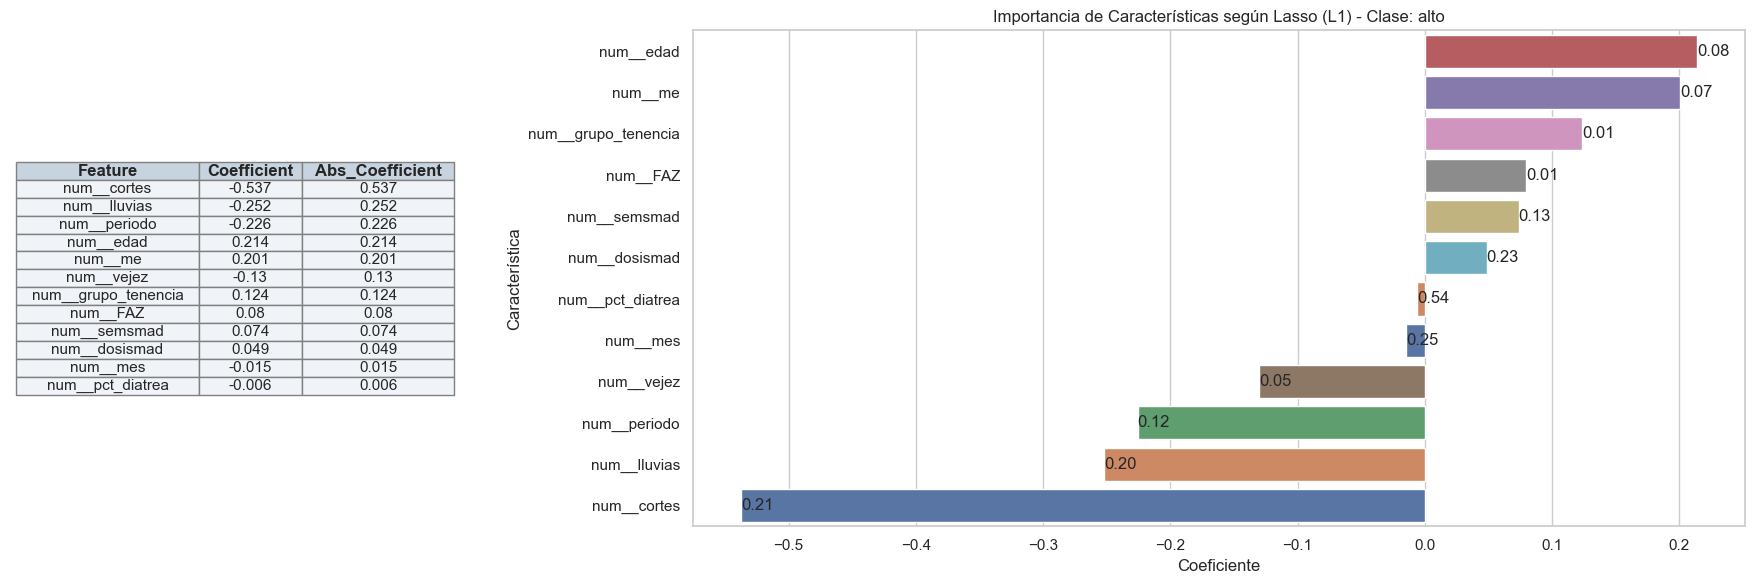

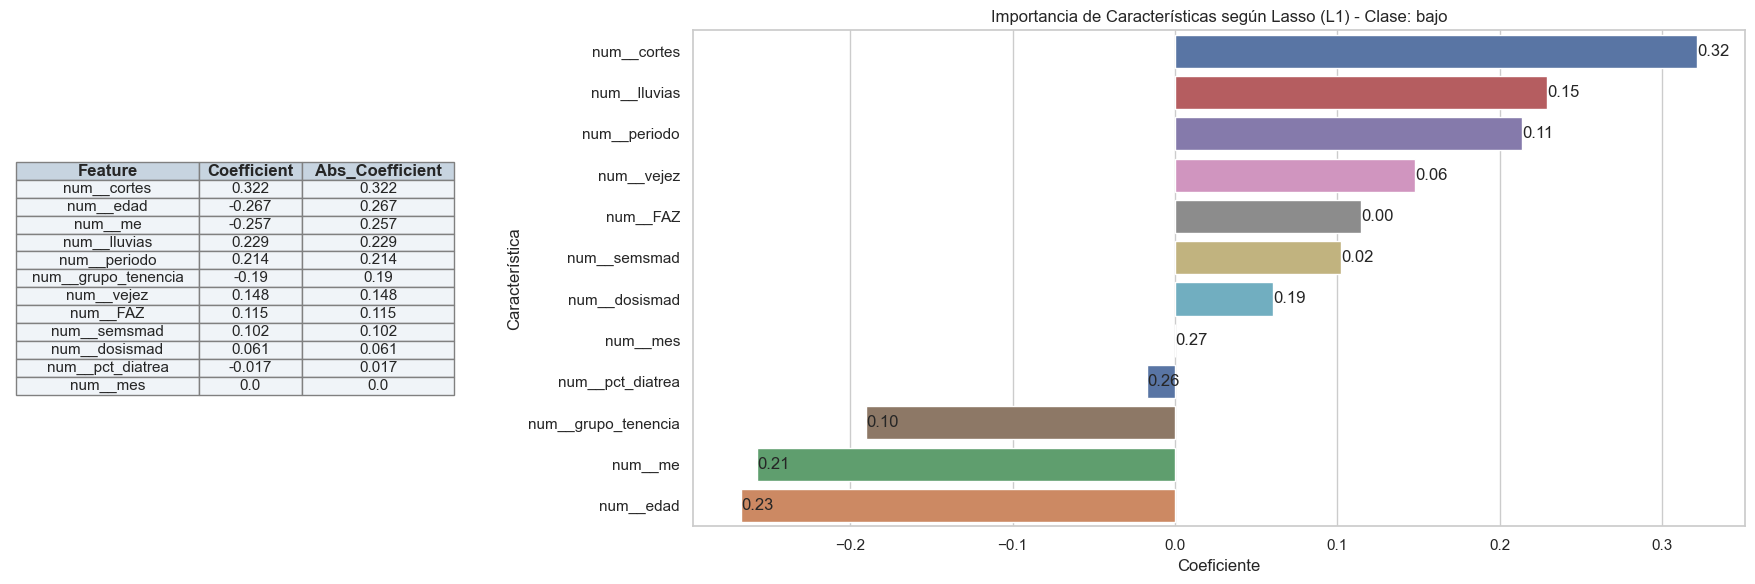

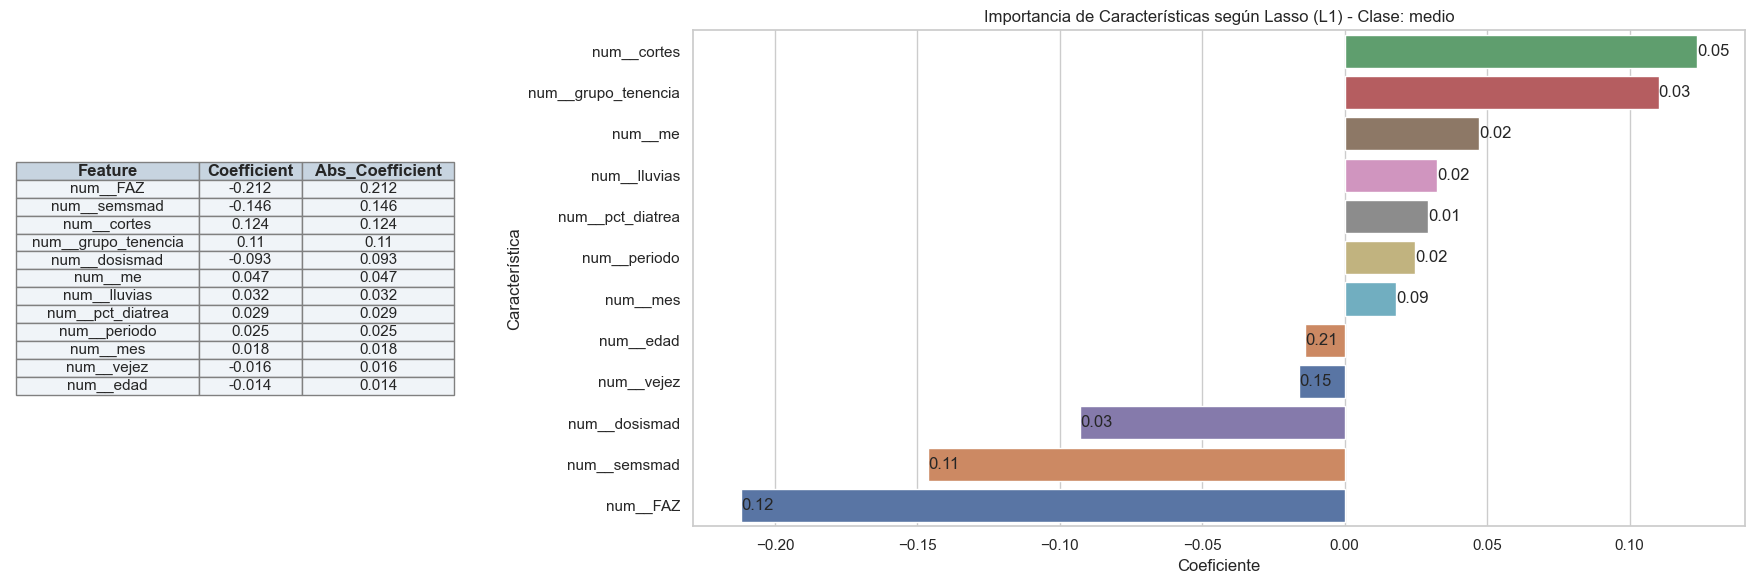

In [79]:
# Nombres de las características y coeficientes del pipeline lasso
feature_names = pipeline_lasso.named_steps['preprocessor'].get_feature_names_out()
coefs = pipeline_lasso.named_steps['classifier'].coef_
classes = pipeline_lasso.named_steps['classifier'].classes_

n_classes = coefs.shape[0]

for i in range(n_classes):
    # Crear DataFrame: coeficientes y sus valores absolutos
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefs[i],
        'Abs_Coefficient': abs(coefs[i])
    })
    # Tabla: ordenar por valor absoluto
    coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Orden para la gráfica: por coeficiente (de mayor a menor)
    ordered_features = coef_df.sort_values('Coefficient', ascending=False)['Feature'].tolist()


    # Crear figura con dos subplots: tabla resumida y gráfico
    fig, (ax_table, ax_plot) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [0.6, 1.4]})

    ax_table.axis('off')

    # Tabla matplotlib con Feature, Coefficient y Abs_Coefficient (valores redondeados)
    table_data = coef_df[['Feature', 'Coefficient', 'Abs_Coefficient']].copy()
    table_data['Coefficient'] = table_data['Coefficient'].round(3)
    table_data['Abs_Coefficient'] = table_data['Abs_Coefficient'].round(3)

    tabla = ax_table.table(
        cellText=table_data.values,
        colLabels=table_data.columns,
        cellLoc='center',
        loc='center'
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(11)
    tabla.auto_set_column_width([0, 1, 2])  # Ajuste por 3 columnas

    # Colorear celdas para mejor legibilidad
    for key, cell in tabla.get_celld().items():
        cell.set_edgecolor('gray')
        if key[0] == 0:  # Header
            cell.set_facecolor('#c7d4e0')
            cell.set_fontsize(12)
            cell.set_text_props(weight='bold')
        else:  # Filas
            cell.set_facecolor('#f0f4f8')

    # Gráfico de barras con coeficientes
    sns.barplot(
        x='Coefficient',
        y='Feature',
        data=coef_df,
        palette='deep',
        order=ordered_features,
        ax=ax_plot,
        hue='Feature')

    ax_plot.set_xlabel('Coeficiente')
    ax_plot.set_ylabel('Característica')
    ax_plot.set_title(f'Importancia de Características según Lasso (L1) - Clase: {classes[i]}')

    # Añadir etiquetas de valor absoluto sobre barras
    for p, abs_val in zip(ax_plot.patches, coef_df.set_index('Feature').loc[ordered_features]['Abs_Coefficient']):
        width = p.get_width()
        ax_plot.text(width, p.get_y() + p.get_height() / 2., f'{abs_val:.2f}', ha='left', va='center')

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.6)
    plt.show()


Coeficientes (Regularización L2 - TCH):

Clase 'alto':


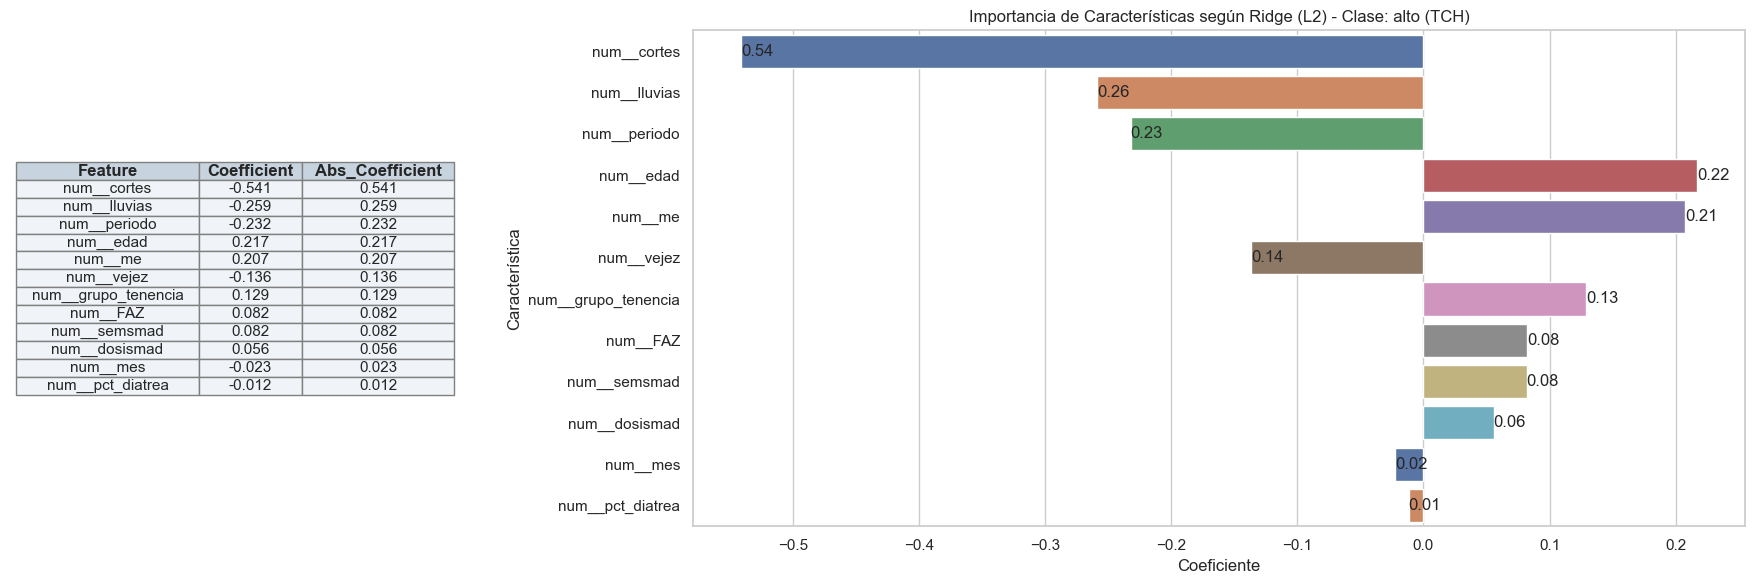


Clase 'bajo':


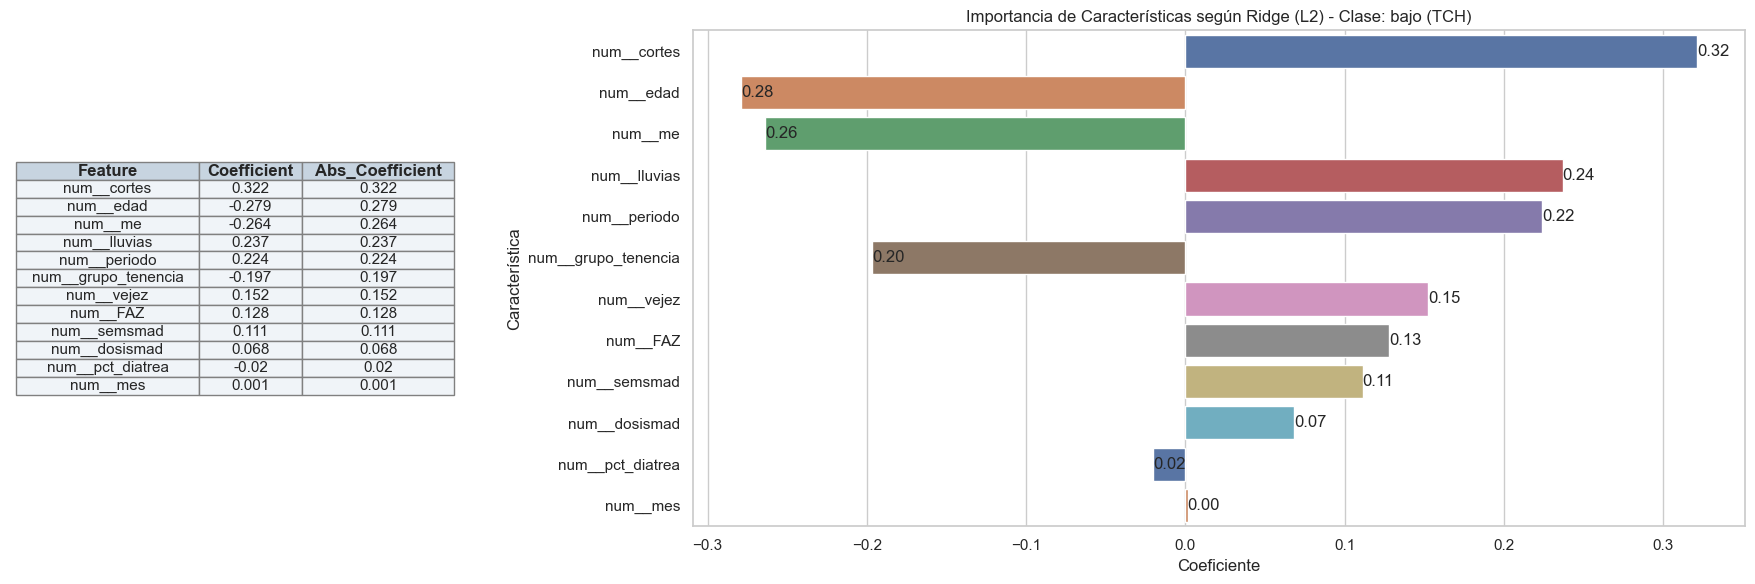


Clase 'medio':


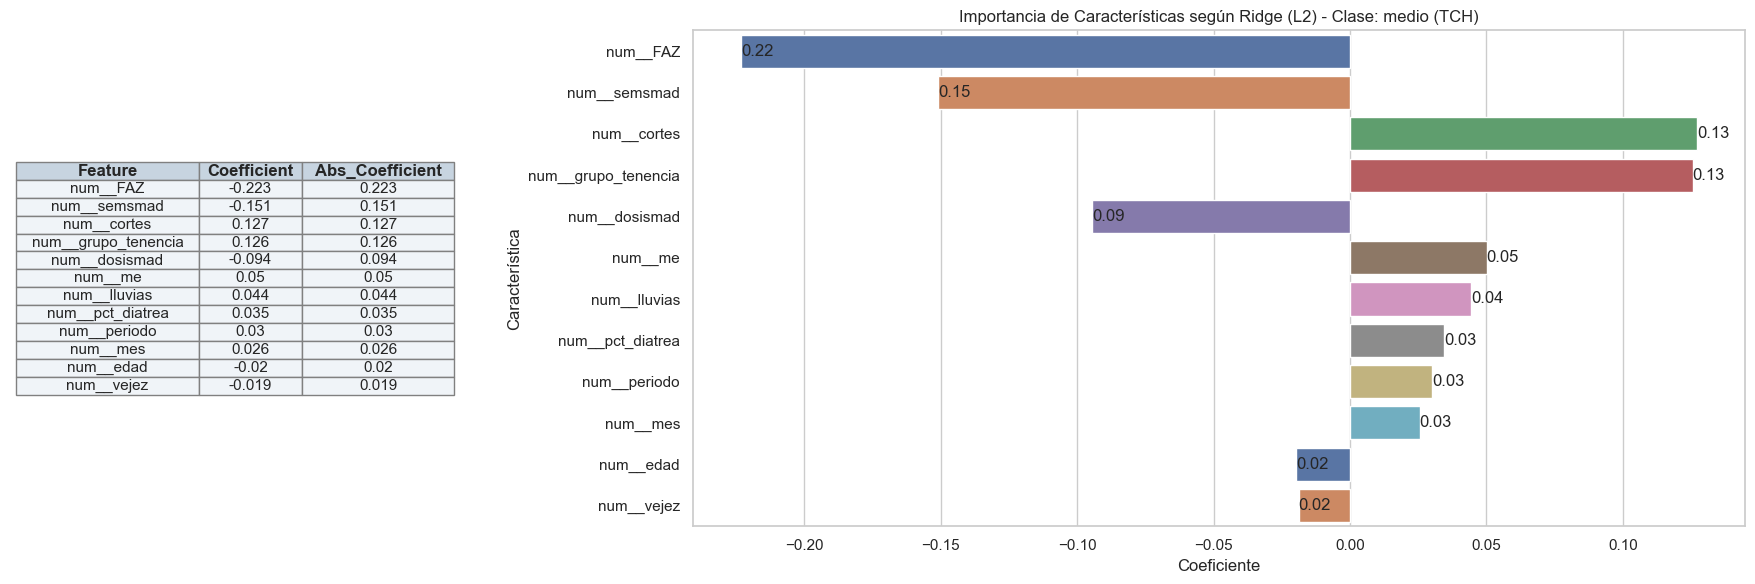

In [80]:
# --- Regresión Logística con Regularización L2 para TCH ---
# Nombres de las características y coeficientes del pipeline (TCH - Ridge)
feature_names_l2_tch = pipeline_ridge.named_steps['preprocessor'].get_feature_names_out()
coefficients_l2_tch = pipeline_ridge.named_steps['classifier'].coef_
classes_l2_tch = pipeline_ridge.named_steps['classifier'].classes_

print("\nCoeficientes (Regularización L2 - TCH):")
for i, class_label in enumerate(classes_l2_tch):
    print(f"\nClase '{class_label}':")
    # Corrected DataFrame creation using coefficients_l2_tch[i]
    coef_df_l2_tch = pd.DataFrame({'Feature': feature_names_l2_tch, 'Coefficient': coefficients_l2_tch[i]})
    coef_df_l2_tch['Abs_Coefficient'] = abs(coef_df_l2_tch['Coefficient'])
    coef_df_l2_tch = coef_df_l2_tch.sort_values(by='Abs_Coefficient', ascending=False) # Sort by absolute coefficient

       # Crear figura con dos subplots: tabla resumida y gráfico
    fig, (ax_table, ax_plot) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [0.6, 1.4]})

    ax_table.axis('off')

    # Mostrar solo Feature y Coefficient redondeado para tabla matplotlib
    table_data_l2_tch = coef_df_l2_tch[['Feature', 'Coefficient', 'Abs_Coefficient']].copy()
    table_data_l2_tch['Coefficient'] = table_data_l2_tch['Coefficient'].round(3)
    table_data_l2_tch['Abs_Coefficient'] = table_data_l2_tch['Abs_Coefficient'].round(3)


    tabla = ax_table.table(
        cellText=table_data_l2_tch.values,
        colLabels=table_data_l2_tch.columns,
        cellLoc='center',
        loc='center')

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(11)
    tabla.auto_set_column_width([0, 1, 2])

    # Cambiar colores para mejor contraste y menos saturación
    for key, cell in tabla.get_celld().items():
        cell.set_edgecolor('gray')
        if key[0] == 0:
            cell.set_facecolor('#c7d4e0')  # Color cabezera
            cell.set_fontsize(12)
            cell.set_text_props(weight='bold')
        else:
            cell.set_facecolor('#f0f4f8')  # Color filas

    # Gráfico de barras con coeficientes
    sns.barplot(
        x='Coefficient',
        y='Feature',
        data=coef_df_l2_tch,
        palette='deep',
        order=coef_df_l2_tch['Feature'],
        ax=ax_plot,
        hue='Feature', # Explicitly set hue
        legend=False # Disable legend
    )
    ax_plot.set_xlabel('Coeficiente')
    ax_plot.set_ylabel('Característica')
    ax_plot.set_title(f'Importancia de Características según Ridge (L2) - Clase: {class_label} (TCH)')

    # Añadir etiquetas de valor absoluto sobre barras
    for p, abs_val in zip(ax_plot.patches, coef_df_l2_tch.set_index('Feature').loc[coef_df_l2_tch['Feature']]['Abs_Coefficient']):
        width = p.get_width()
        ax_plot.text(width, p.get_y() + p.get_height() / 2., f'{abs_val:.2f}', ha='left', va='center')

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.6) # Ajusta el espacio vertical entre gráficos
    plt.show()

##### **Nota:**

* La regularización L1 y L2 no parecen haber tenido un impacto significativo en la métrica de Accuracy general para el modelo de TCH en comparación con el modelo sin regularización. En los reportes de clasificación entre los 3 modelos, se observa que:

    * Para la clase "alto" en el modelo TCH, ni la regularización L1 ni la L2 tuvieron un impacto notable en la precisión, recall o F1-score. El rendimiento para predecir correctamente esta clase se mantuvo similar.

    * El impacto de la regularización en la clase "bajo" del modelo TCH fue mínimo. Hubo un ligero aumento en la precisión y recall con L1, pero el F1-score se mantuvo igual.

    * Para la clase "medio" la regularización no logró mejorar el rendimiento, de hecho el recall y F1-score con L1 disminuyeron ligeramente.

* Se decide manejar la regularización L1 porque tiende a llevar los coeficientes de características menos importantes a cero, lo que puede ayudar en la selección de características que si aporten a la predicción de la variable objetivo TCH. Después de comparar el gráfico de importancia de caracteristicas por cada una de las clases, se observa que variables que pueden ser eliminadas son: 'mes', 'pct_diatrea', y 'dosismad'

#### **Regresión logística regularizado L1 con coeficientes de variables > 0.10**

In [81]:
# Definición de variable dependientes e independiente.
# Excluyendo las variables 'mes', 'pct_diatrea', y 'dosismad'
X_tch = df_limpio.drop(columns= ['sacarosa', 'TCH','TCH_categoria', 'Sac_categoria', 'mes', 'pct_diatrea', 'dosismad'])
y_tch = df_limpio["TCH_categoria"]


# Division conjuntos de entrenamiento y prueba
X_train_tch, X_test_tch, y_train_tch, y_test_tch = train_test_split(X_tch, y_tch, test_size=0.3, random_state=42, stratify=y_tch)

#Dimensiones del dataframe
print("Dimensiones de X_train:", X_train_tch.shape)
print("Dimensiones de X_test:", X_test_tch.shape)
print("Dimensiones de y_train:", y_train_tch.shape)
print("Dimensiones de y_test:", y_test_tch.shape)

Dimensiones de X_train: (951, 9)
Dimensiones de X_test: (408, 9)
Dimensiones de y_train: (951,)
Dimensiones de y_test: (408,)


In [82]:
# Identificación de columnas numéricas y categóricas
num_cols_tch = X_tch.select_dtypes(include=np.number).columns.tolist()
cat_cols_tch = X_tch.select_dtypes(include=['object', 'category']).columns.tolist()


#Crear preprocesador con ColumnTransformer usando Pipeline
preprocessor_tch = ColumnTransformer([("num", StandardScaler(), num_cols_tch),("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown='ignore'), cat_cols_tch)])

print("Preprocesador para TCH configurado.")

Preprocesador para TCH configurado.


In [83]:
# Pipeline para regresión logística
pipeline_tch = Pipeline([("prep", preprocessor_tch), ("clf", LogisticRegression(solver='liblinear', max_iter=1000))])

# Entrenar modelo
softmax_model_tch = pipeline_tch.fit(X_train_tch, y_train_tch)

print("Modelo de Regresión Logística para TCH entrenado exitosamente.")

Modelo de Regresión Logística para TCH entrenado exitosamente.


c:\Users\mafab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Reporte de clasificación:
              precision    recall  f1-score   support

        alto       0.52      0.69      0.60       138
        bajo       0.47      0.60      0.53       140
       medio       0.31      0.12      0.17       130

    accuracy                           0.48       408
   macro avg       0.44      0.47      0.43       408
weighted avg       0.44      0.48      0.44       408

Exactitud: 0.47549019607843135
Matriz de Confusión:
[[95 26 17]
 [40 84 16]
 [46 69 15]]


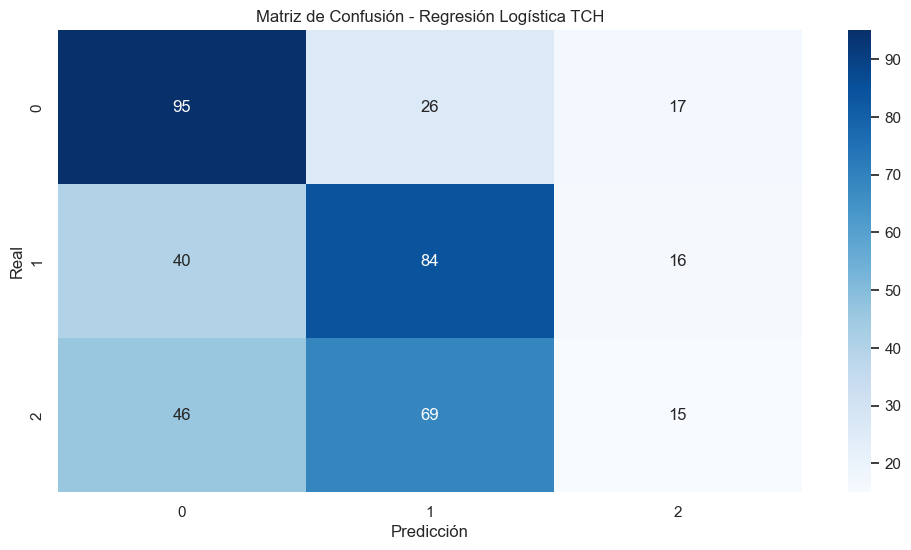

In [84]:
# Predecir
y_pred_tch = softmax_model_tch.predict(X_test_tch)

# Evaluar
print("Reporte de clasificación:")
print(classification_report(y_test_tch, y_pred_tch))

print("="*40)

print("Exactitud:", accuracy_score(y_test_tch, y_pred_tch))

print("="*40)

# Calcular matriz de confusión
cm_tch = confusion_matrix(y_test_tch, y_pred_tch)
print("Matriz de Confusión:")
print(cm_tch)

print("="*40)

# Visualización gráfica
sns.heatmap(cm_tch, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Regresión Logística TCH')
plt.show()

#### **Modelo KNN TCH**


--- KNN para TCH ---

Informe de Clasificación (KNN - TCH):
              precision    recall  f1-score   support

        alto       0.52      0.70      0.60       138
        bajo       0.52      0.54      0.53       140
       medio       0.34      0.19      0.25       130

    accuracy                           0.49       408
   macro avg       0.46      0.48      0.46       408
weighted avg       0.46      0.49      0.46       408

Matriz de Confusión (KNN - TCH):
[[97 19 22]
 [37 76 27]
 [53 52 25]]


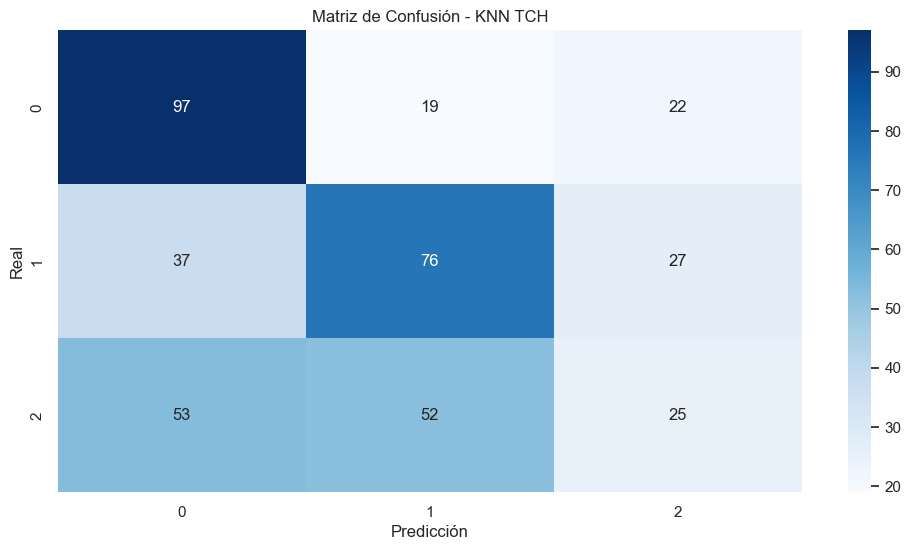

In [85]:
# --- Modelo KNN para TCH ---
print("\n--- KNN para TCH ---")
# El modelo KNN no utiliza un "solver" como la Regresión Logística.
knn_tch = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', KNeighborsClassifier())])

knn_tch.fit(X_train, y_train)
y_pred_knn_tch = knn_tch.predict(X_test)

print("\nInforme de Clasificación (KNN - TCH):")
print(classification_report(y_test, y_pred_knn_tch))

print("="*40)

# Calcular matriz de confusión
cm_knn_tch = confusion_matrix(y_test, y_pred_knn_tch)
print("Matriz de Confusión (KNN - TCH):")
print(cm_knn_tch)

print("="*40)

# Visualización gráfica
sns.heatmap(cm_knn_tch, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - KNN TCH')
plt.show()

### **Variable objetiva Sacarosa**

#### **Regresión logística sin regularización**

In [86]:
# Definición de variable dependientes e independiente para Sac_categoria.
X_sac = df_limpio.drop(columns=['sacarosa', 'TCH','TCH_categoria', 'Sac_categoria'])
y_sac = df_limpio["Sac_categoria"]

# Division conjuntos de entrenamiento y prueba
X_train_sac, X_test_sac, y_train_sac, y_test_sac = train_test_split(X_sac, y_sac, test_size=0.3, random_state=42, stratify=y_sac)

# Dimensiones de los dataframes de entrenamiento y prueba
print("Dimensiones de X_train_sac:", X_train_sac.shape)
print("Dimensiones de X_test_sac:", X_test_sac.shape)
print("Dimensiones de y_train_sac:", y_train_sac.shape)
print("Dimensiones de y_test_sac:", y_test_sac.shape)

Dimensiones de X_train_sac: (951, 12)
Dimensiones de X_test_sac: (408, 12)
Dimensiones de y_train_sac: (951,)
Dimensiones de y_test_sac: (408,)


In [87]:
# Identificación de columnas numéricas y categóricas para el modelo Sac_categoria
num_cols_sac = X_sac.select_dtypes(include=np.number).columns.tolist()
cat_cols_sac = X_sac.select_dtypes(include=['object', 'category']).columns.tolist()

#Crear preprocesador con ColumnTransformer usando Pipeline para Sac_categoria
preprocessor_sac = ColumnTransformer([("num", StandardScaler(), num_cols_sac),("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown='ignore'), cat_cols_sac)])

print("Preprocesador para Sac_categoria configurado.")

Preprocesador para Sac_categoria configurado.


In [88]:
# Pipeline para regresión logística para Sac_categoria
pipeline_sac = Pipeline([("prep", preprocessor_sac),("clf", LogisticRegression(solver='liblinear', max_iter=1000))])

# Entrenar modelo para Sac_categoria
softmax_model_sac = pipeline_sac.fit(X_train_sac, y_train_sac)

print("Modelo de Regresión Logística para Sac_categoria entrenado exitosamente.")
display(pipeline_sac)

Modelo de Regresión Logística para Sac_categoria entrenado exitosamente.


c:\Users\mafab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Reporte de clasificación Sac_categoria:
              precision    recall  f1-score   support

        alto       0.50      0.65      0.57       137
        bajo       0.50      0.70      0.58       151
       medio       0.28      0.04      0.07       120

    accuracy                           0.49       408
   macro avg       0.43      0.46      0.41       408
weighted avg       0.43      0.49      0.43       408

Exactitud: 0.49019607843137253
Matriz de Confusión:
[[ 89  41   7]
 [ 39 106   6]
 [ 50  65   5]]


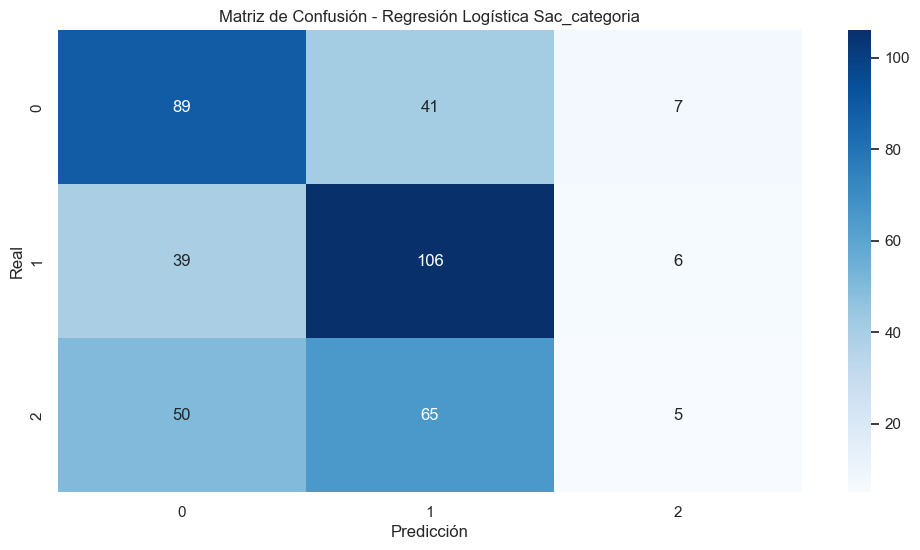

In [89]:
# Predecir
y_pred_sac = softmax_model_sac.predict(X_test_sac)

# Evaluar
print("Reporte de clasificación Sac_categoria:")
print(classification_report(y_test_sac, y_pred_sac))

print("="*40)

print("Exactitud:", accuracy_score(y_test_sac, y_pred_sac))

print("="*40)

# Calcular matriz de confusión
cm_sac = confusion_matrix(y_test_sac, y_pred_sac)
print("Matriz de Confusión:")
print(cm_sac)

print("="*40)

# Visualización gráfica
sns.heatmap(cm_sac, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Regresión Logística Sac_categoria')
plt.show()

Probabilidades por clase para la primera muestra de test:
 [0.52394   0.1499442 0.3261158]


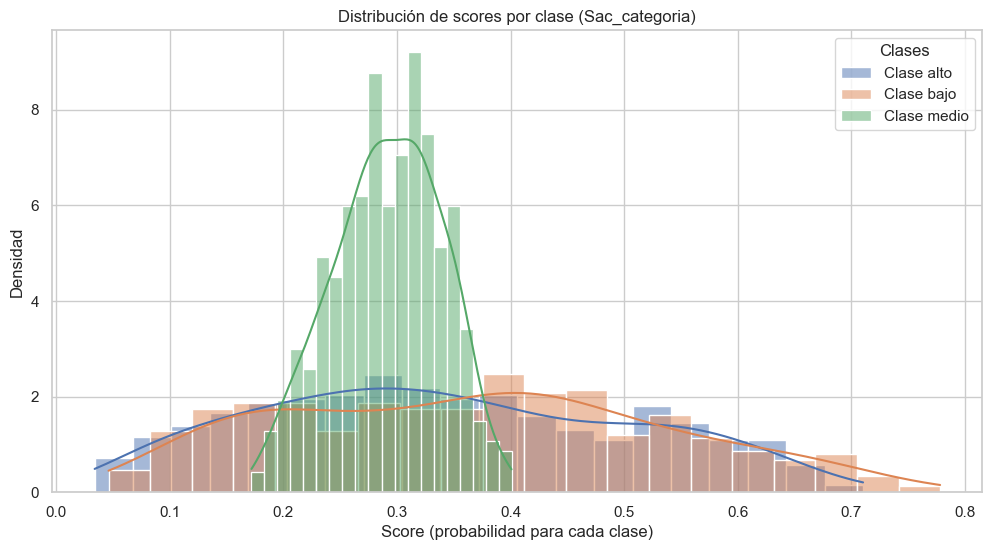

In [90]:
# Obtener probabilidades de pertenecer a cada clase para el modelo Sac_categoria
y_prob_sac = softmax_model_sac.predict_proba(X_test_sac)

# Visualizar probabilidades de la primera muestra como ejemplo
print("Probabilidades por clase para la primera muestra de test:\n", y_prob_sac[0])

print("="*40)

# Visualización tipo histograma/kde para los scores de cada clase para el modelo Sac_categoria
plt.figure(figsize=(12, 6))
for idx, clase in enumerate(pipeline_sac.named_steps['clf'].classes_):
    scores_clase_sac = y_prob_sac[:, idx]
    sns.histplot(scores_clase_sac, kde=True, bins=20, label=f'Clase {clase}', stat='density')

plt.xlabel("Score (probabilidad para cada clase)")
plt.ylabel("Densidad")
plt.legend(title="Clases")
plt.title("Distribución de scores por clase (Sac_categoria)")
plt.show()

#### **Regresión logística regularizado con L1 y L2**

In [91]:
# Aplicando Regularización (L1 y L2) al Modelo de Clasificación de sacarosa

# Pipeline para regresión logística con regularización L2 (Ridge) para el modelo sacarosa
pipeline_ridge_sac = Pipeline(steps=[
    ('preprocessor', preprocessor_sac),
    ('classifier', LogisticRegression(penalty='l2', solver='liblinear', random_state=42, max_iter=1000))
])

# Pipeline para regresión logística con regularización L1 (Lasso) para el modelo sacarosa
pipeline_lasso_sac = Pipeline(steps=[
    ('preprocessor', preprocessor_sac),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000))
])

# Entrenar los modelos con regularización (para sacarosa)
pipeline_ridge_sac.fit(X_train_sac, y_train_sac)
pipeline_lasso_sac.fit(X_train_sac, y_train_sac)

# Predecir con ambos modelos (para sacarosa)
y_pred_ridge_sac = pipeline_ridge_sac.predict(X_test_sac)
y_pred_lasso_sac = pipeline_lasso_sac.predict(X_test_sac)

# Evaluar ambos modelos (para sacarosa)
print("Evaluación Regularización L2 (Ridge) - Modelo sacarosa:")
print(classification_report(y_test_sac, y_pred_ridge_sac))
print("Exactitud L2 - Modelo sacarosa:", accuracy_score(y_test_sac, y_pred_ridge_sac))

print("="*60)


print("\nEvaluación Regularización L1 (Lasso) - Modelo sacarosa:")
print(classification_report(y_test_sac, y_pred_lasso_sac))
print("Exactitud L1 - Modelo sacarosa:", accuracy_score(y_test_sac, y_pred_lasso_sac))

Evaluación Regularización L2 (Ridge) - Modelo sacarosa:
              precision    recall  f1-score   support

        alto       0.50      0.65      0.57       137
        bajo       0.50      0.70      0.58       151
       medio       0.28      0.04      0.07       120

    accuracy                           0.49       408
   macro avg       0.43      0.46      0.41       408
weighted avg       0.43      0.49      0.43       408

Exactitud L2 - Modelo sacarosa: 0.49019607843137253

Evaluación Regularización L1 (Lasso) - Modelo sacarosa:
              precision    recall  f1-score   support

        alto       0.50      0.65      0.57       137
        bajo       0.50      0.71      0.59       151
       medio       0.29      0.04      0.07       120

    accuracy                           0.49       408
   macro avg       0.43      0.47      0.41       408
weighted avg       0.44      0.49      0.43       408

Exactitud L1 - Modelo sacarosa: 0.49264705882352944


c:\Users\mafab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\mafab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


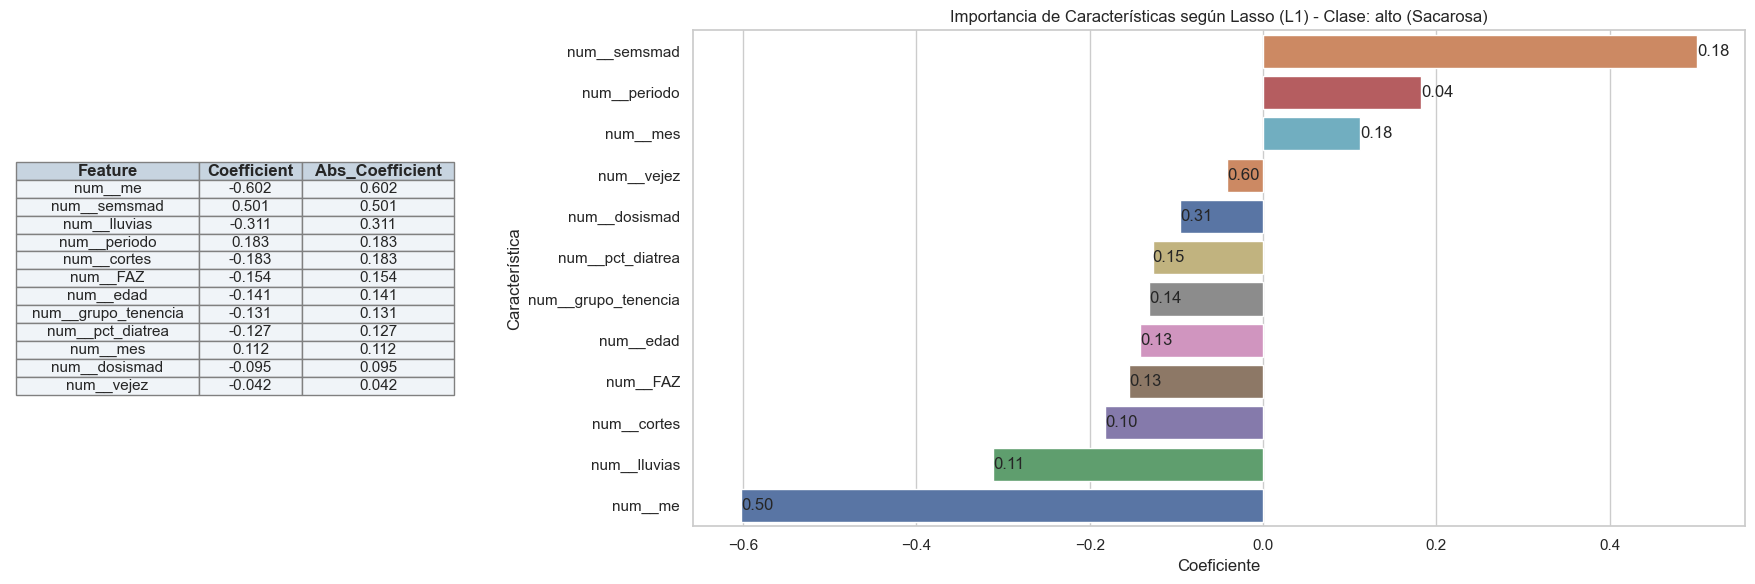

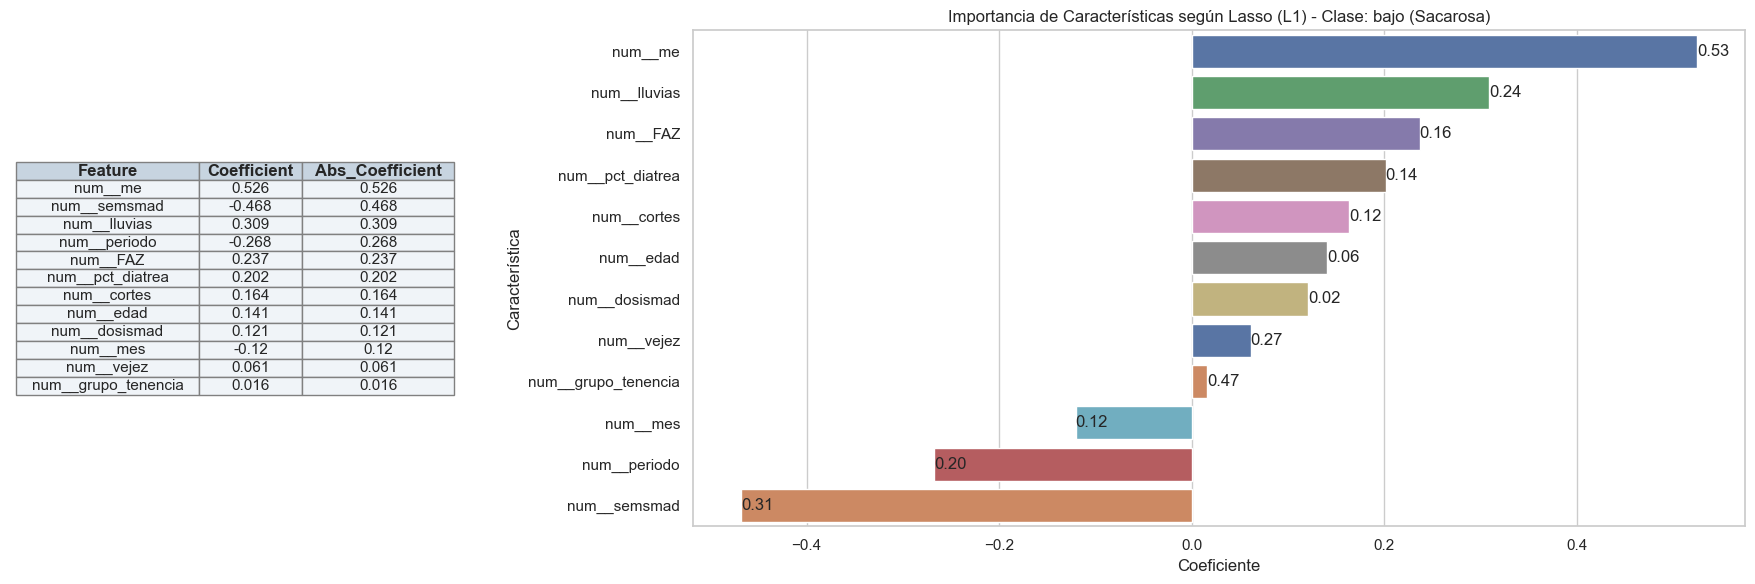

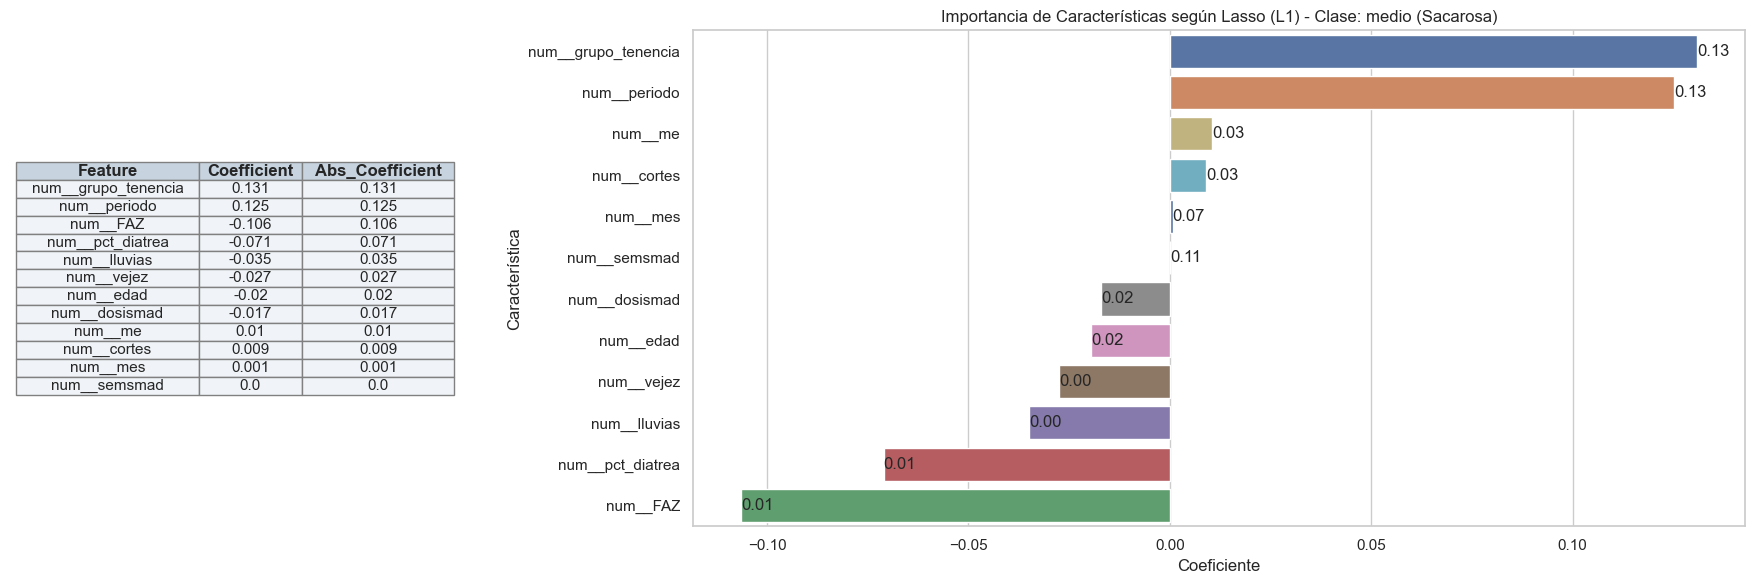

In [92]:
# Nombres de las características y coeficientes del pipeline (Sacarosa - Lasso)
feature_names_sac = pipeline_lasso_sac.named_steps['preprocessor'].get_feature_names_out()
coefs_sac = pipeline_lasso_sac.named_steps['classifier'].coef_
classes_sac = pipeline_lasso_sac.named_steps['classifier'].classes_

n_classes_sac = coefs_sac.shape[0]

for i in range(n_classes_sac):
    # Crear DataFrame: coeficientes y sus valores absolutos
    coef_df_sac = pd.DataFrame({
        'Feature': feature_names_sac,
        'Coefficient': coefs_sac[i],
        'Abs_Coefficient': abs(coefs_sac[i])
    })
    # Tabla: ordenar por valor absoluto
    coef_df_sac = coef_df_sac.sort_values(by='Abs_Coefficient', ascending=False)

    # Orden para la gráfica: por coeficiente (de mayor a menor)
    ordered_features_sac = coef_df_sac.sort_values('Coefficient', ascending=False)['Feature'].tolist()


    # Crear figura con dos subplots: tabla resumida y gráfico
    fig, (ax_table, ax_plot) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [0.6, 1.4]})

    ax_table.axis('off')

    # Mostrar solo Feature y Coefficient redondeado para tabla matplotlib
    table_data_sac = coef_df_sac[['Feature', 'Coefficient']].copy()
    table_data_sac['Coefficient'] = table_data_sac['Coefficient'].round(3)
    table_data_sac['Abs_Coefficient'] = coef_df_sac['Abs_Coefficient'].round(3)

    tabla = ax_table.table(
        cellText=table_data_sac.values,
        colLabels=table_data_sac.columns,
        cellLoc='center',
        loc='center')

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(11)
    tabla.auto_set_column_width([0, 1, 2])

    # Cambiar colores para mejor contraste y menos saturación
    for key, cell in tabla.get_celld().items():
        cell.set_edgecolor('gray')
        if key[0] == 0:
            cell.set_facecolor('#c7d4e0')  # Color cabezera
            cell.set_fontsize(12)
            cell.set_text_props(weight='bold')
        else:
            cell.set_facecolor('#f0f4f8')  # Color filas

    # Gráfico de barras con coeficientes
    sns.barplot(
        x='Coefficient',
        y='Feature',
        data=coef_df_sac,
        palette='deep',
        order=ordered_features_sac,
        ax=ax_plot,
        hue='Feature')

    ax_plot.set_xlabel('Coeficiente')
    ax_plot.set_ylabel('Característica')
    ax_plot.set_title(f'Importancia de Características según Lasso (L1) - Clase: {classes_sac[i]} (Sacarosa)')

    # Añadir etiquetas de valor absoluto sobre barras
    for p, abs_val in zip(ax_plot.patches, coef_df_sac.set_index('Feature').loc[ordered_features_sac]['Abs_Coefficient']):
        width = p.get_width()
        ax_plot.text(width, p.get_y() + p.get_height() / 2., f'{abs_val:.2f}', ha='left', va='center')

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.6) # Ajusta el espacio vertical entre gráficos
    plt.show()


Coeficientes (Regularización L2 - %Sac.Caña):

Clase 'alto':


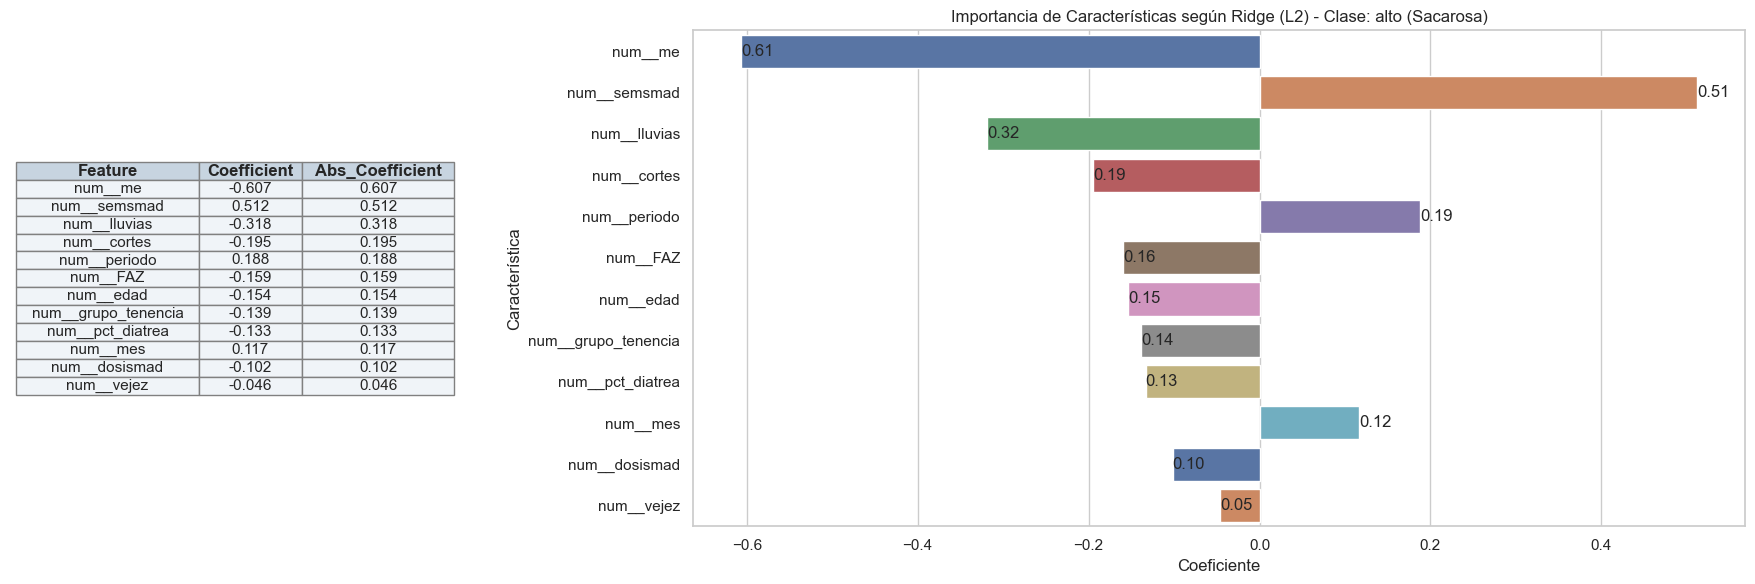


Clase 'bajo':


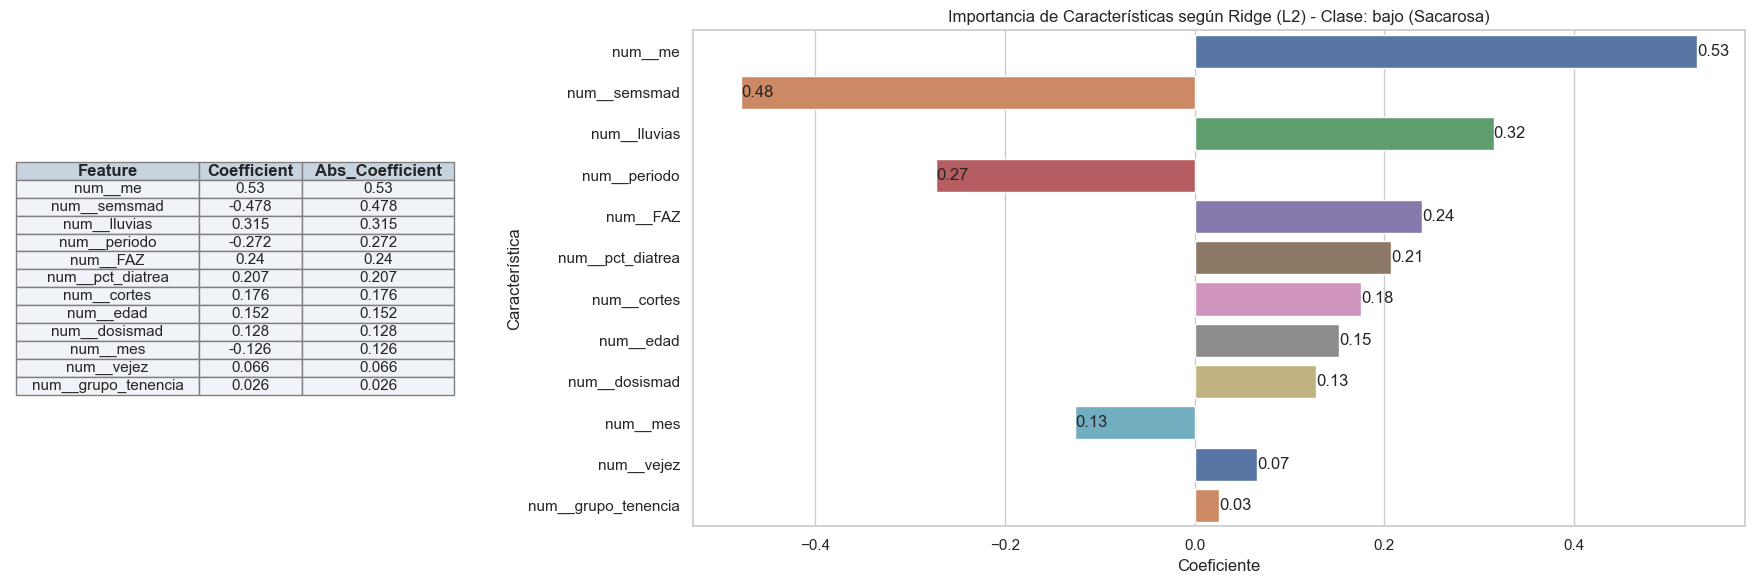


Clase 'medio':


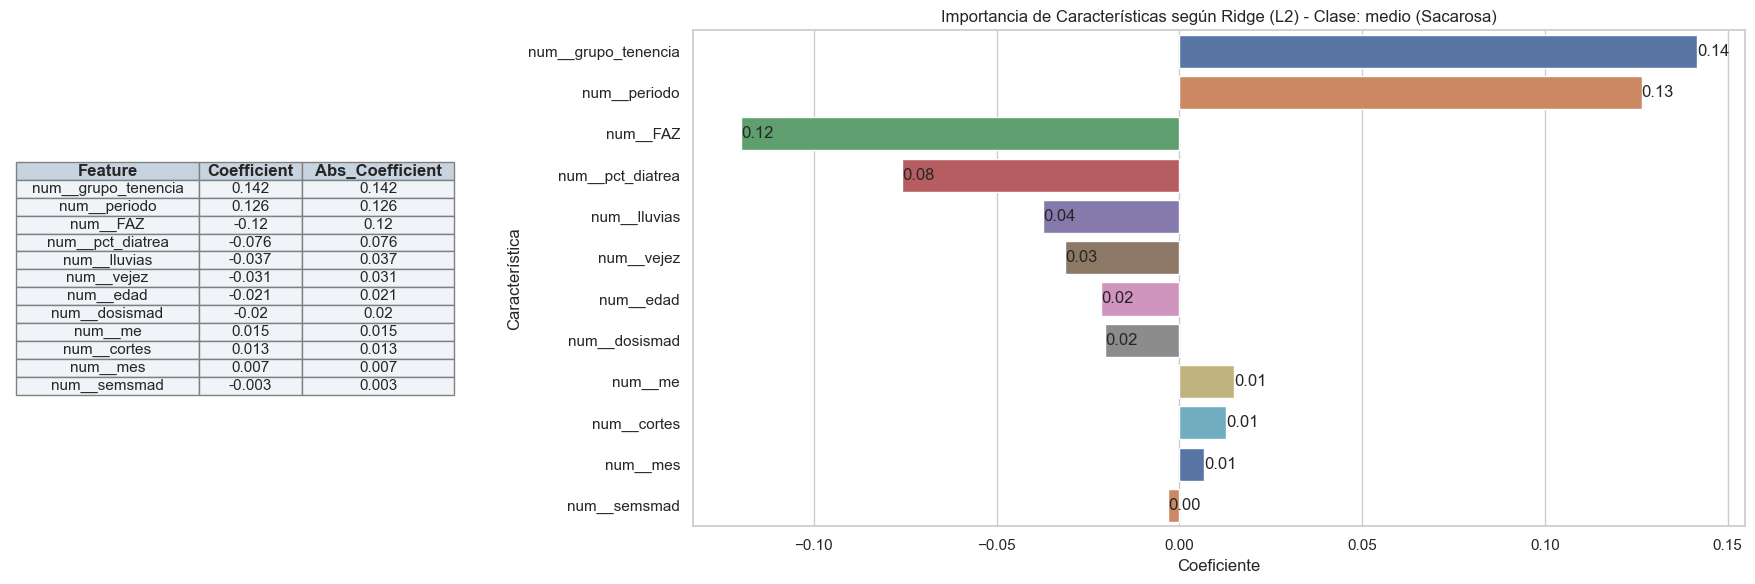


Interpretación de los Coeficientes con L1 vs L2:
La regularización L1 (Lasso) tiende a llevar los coeficientes de las características menos importantes a cero, lo que puede ser útil para la selección de características.
La regularización L2 (Ridge) tiende a reducir la magnitud de los coeficientes sin llevarlos completamente a cero.
Comparando los coeficientes de los modelos L1 y L2, puedes observar cómo cada tipo de regularización afecta la importancia relativa de las variables.


In [93]:
# Nombres de las características y coeficientes del pipeline (Sacarosa - Ridge)
feature_names_sac_ridge = pipeline_ridge_sac.named_steps['preprocessor'].get_feature_names_out()
coefficients_sac_ridge = pipeline_ridge_sac.named_steps['classifier'].coef_
classes_sac_ridge = pipeline_ridge_sac.named_steps['classifier'].classes_

print("\nCoeficientes (Regularización L2 - %Sac.Caña):")
for i, class_label in enumerate(classes_sac_ridge):
    print(f"\nClase '{class_label}':")
    coef_df_sac_ridge = pd.DataFrame({'Feature': feature_names_sac_ridge, 'Coefficient': coefficients_sac_ridge[i]})
    coef_df_sac_ridge['Abs_Coefficient'] = abs(coef_df_sac_ridge['Coefficient'])
    coef_df_sac_ridge = coef_df_sac_ridge.sort_values(by='Abs_Coefficient', ascending=False) # Sort by absolute coefficient

        # Crear figura con dos subplots: tabla resumida y gráfico
    fig, (ax_table, ax_plot) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [0.6, 1.4]})

    ax_table.axis('off')

    # Mostrar solo Feature y Coefficient redondeado para tabla matplotlib
    table_data_sac_ridge = coef_df_sac_ridge[['Feature', 'Coefficient', 'Abs_Coefficient']].copy()
    table_data_sac_ridge['Coefficient'] = table_data_sac_ridge['Coefficient'].round(3)
    table_data_sac_ridge['Abs_Coefficient'] = table_data_sac_ridge['Abs_Coefficient'].round(3)

    tabla = ax_table.table(
        cellText=table_data_sac_ridge.values,
        colLabels=table_data_sac_ridge.columns,
        cellLoc='center',
        loc='center')

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(11)
    tabla.auto_set_column_width([0, 1, 2])

    # Cambiar colores para mejor contraste y menos saturación
    for key, cell in tabla.get_celld().items():
        cell.set_edgecolor('gray')
        if key[0] == 0:
            cell.set_facecolor('#c7d4e0')  # Color cabezera
            cell.set_fontsize(12)
            cell.set_text_props(weight='bold')
        else:
            cell.set_facecolor('#f0f4f8')  # Color filas

    # Gráfico de barras con coeficientes
    sns.barplot(
        x='Coefficient',
        y='Feature',
        data=coef_df_sac_ridge,
        palette='deep',
        order=coef_df_sac_ridge['Feature'],
        ax=ax_plot,
        hue='Feature', # Explicitly set hue
        legend=False # Disable legend
    )
    ax_plot.set_xlabel('Coeficiente')
    ax_plot.set_ylabel('Característica')
    ax_plot.set_title(f'Importancia de Características según Ridge (L2) - Clase: {class_label} (Sacarosa)')

    # Añadir etiquetas de valor absoluto sobre barras
    for p, abs_val in zip(ax_plot.patches, coef_df_sac_ridge.set_index('Feature').loc[coef_df_sac_ridge['Feature']]['Abs_Coefficient']):
        width = p.get_width()
        ax_plot.text(width, p.get_y() + p.get_height() / 2., f'{abs_val:.2f}', ha='left', va='center')

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.6) # Ajusta el espacio vertical entre gráficos
    plt.show()

print("\nInterpretación de los Coeficientes con L1 vs L2:")
print("La regularización L1 (Lasso) tiende a llevar los coeficientes de las características menos importantes a cero, lo que puede ser útil para la selección de características.")
print("La regularización L2 (Ridge) tiende a reducir la magnitud de los coeficientes sin llevarlos completamente a cero.")
print("Comparando los coeficientes de los modelos L1 y L2, puedes observar cómo cada tipo de regularización afecta la importancia relativa de las variables.")

##### **Nota:**

* La regularización L2 (Ridge) parece haber ofrecido una mejora mínima para el modelo de Sac_categoria, debido a que mostró un Accuracy ligeramente mayor a los modelo sin regularización y L1. De igual forma, en los reportes de clasificación entre los 3 modelos, se observa que:

    * Para la clase 'alto' en el modelo sac_categoria, ambas regularizaciones (L1 y L2) mostraron una mejora en la precisión y el F1-score en comparación con el modelo sin regularización.

    * El impacto de la regularización en la clase "bajo" del modelo sac_categoria, se mantuvo muy similar con o sin regularización. Hubo un ligero aumento en el recall con L1, pero las otras métricas se mantuvieron iguales.

    * Para la clase "medio" la regularización no logró mejorar el rendimiento, de hecho con L1, las métricas para esta clase disminuyeron.


#### **Modelo KNN Sacarosa**


--- KNN para Sacarosa ---

Informe de Clasificación (KNN - Sacarosa):
              precision    recall  f1-score   support

        alto       0.51      0.68      0.58       137
        bajo       0.57      0.66      0.61       151
       medio       0.31      0.12      0.18       120

    accuracy                           0.51       408
   macro avg       0.46      0.49      0.46       408
weighted avg       0.47      0.51      0.47       408

Matriz de Confusión (KNN - Sacarosa):
[[ 93  27  17]
 [ 34 100  17]
 [ 57  48  15]]


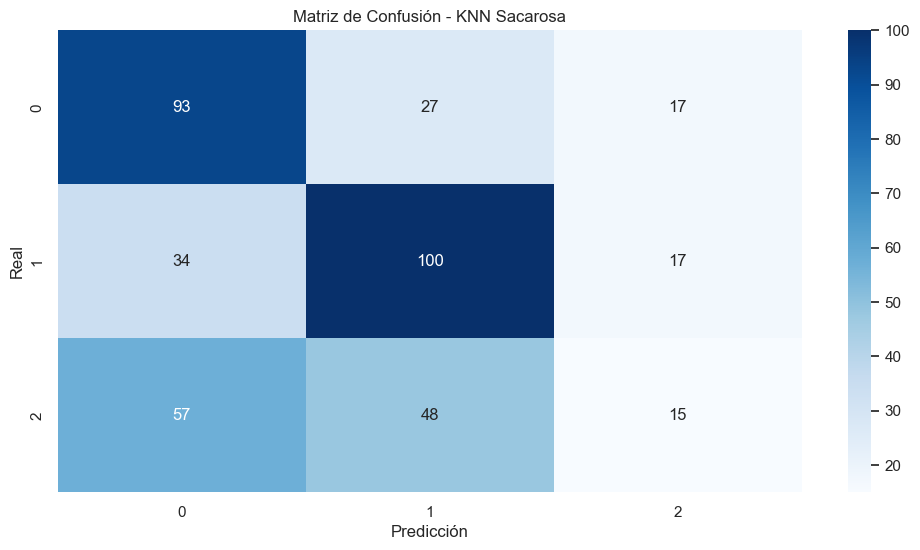

In [94]:
# --- Modelo KNN para Sacarosa ---
print("\n--- KNN para Sacarosa ---")
knn_sac = Pipeline(steps=[('preprocessor', preprocessor_sac),
                          ('classifier', KNeighborsClassifier())])


knn_sac.fit(X_train_sac, y_train_sac)
y_pred_knn_sac = knn_sac.predict(X_test_sac)

print("\nInforme de Clasificación (KNN - Sacarosa):")
print(classification_report(y_test_sac, y_pred_knn_sac))

print("="*40)

# Calcular matriz de confusión
cm_knn_sac = confusion_matrix(y_test_sac, y_pred_knn_sac)
print("Matriz de Confusión (KNN - Sacarosa):")
print(cm_knn_sac)

print("="*40)

# Visualización gráfica
sns.heatmap(cm_knn_sac, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - KNN Sacarosa')
plt.show()

## **Validación y Evaluación:**

Emplear una estrategia de validación (por ejemplo, validación cruzada) y justificar la elección.
Reportar y analizar métricas de evaluación para clasificación (accuracy, precision, recall, F1-score, kappa.).

In [95]:
# --- Reportar Métricas para Regresión Logística (TCH) ---
# Reportar las métricas de evaluación para el modelo de Regresión Logística en la variable TCH
print("--- Métricas de Evaluación para Regresión Logística sin regularización (TCH) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}") # Calcula y imprime la Exactitud
print(f"Precision (weighted): {precision_score(y_test, y_pred, average='weighted'):.4f}") # Calcula y imprime la Precisión ponderada
print(f"Recall (weighted): {recall_score(y_test, y_pred, average='weighted'):.4f}") # Calcula y imprime el Recall ponderado
print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}") # Calcula y imprime el F1-score ponderado
print(f"Kappa: {cohen_kappa_score(y_test, y_pred):.4f}") # Calcula y imprime el coeficiente Kappa de Cohen

print("="*60)

# --- Reportar Métricas para KNN (TCH) ---
# Reportar las métricas de evaluación para el modelo KNN en la variable TCH
print("\n--- Métricas de Evaluación para KNN (TCH) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn_tch):.4f}") # Calcula y imprime la Exactitud
print(f"Precision (weighted): {precision_score(y_test, y_pred_knn_tch, average='weighted'):.4f}") # Calcula y imprime la Precisión ponderada
print(f"Recall (weighted): {recall_score(y_test, y_pred_knn_tch, average='weighted'):.4f}") # Calcula y imprime el Recall ponderado
print(f"F1-score (weighted): {f1_score(y_test, y_pred_knn_tch, average='weighted'):.4f}") # Calcula y imprime el F1-score ponderado
print(f"Kappa: {cohen_kappa_score(y_test, y_pred_knn_tch):.4f}") # Calcula y imprime el coeficiente Kappa de Cohen

print("="*60)

# --- Reportar Métricas para Regresión Logística Regularizado L1 (TCH, coef > 0.10) ---
# Reportar las métricas de evaluación para el modelo de Regresión Logística con regularización L1 (coeficientes > 0.10) en la variable TCH
print("\n--- Métricas de Evaluación para Regresión Logística Regularizado L1 (TCH, coef > 0.10) ---")
print(f"Accuracy: {accuracy_score(y_test_tch, y_pred_tch):.4f}") # Calcula y imprime la Exactitud
print(f"Precision (weighted): {precision_score(y_test_tch, y_pred_tch, average='weighted'):.4f}") # Calcula y imprime la Precisión ponderada
print(f"Recall (weighted): {recall_score(y_test_tch, y_pred_tch, average='weighted'):.4f}") # Calcula y imprime el Recall ponderado
print(f"F1-score (weighted): {f1_score(y_test_tch, y_pred_tch, average='weighted'):.4f}") # Calcula y imprime el F1-score ponderado
print(f"Kappa: {cohen_kappa_score(y_test_tch, y_pred_tch):.4f}") # Calcula y imprime el coeficiente Kappa de Cohen

print("="*60)

# --- Reportar Métricas para Regresión Logística (%Sac.Caña) ---
# Reportar las métricas de evaluación para el modelo de Regresión Logística en la variable Sacarosa
print("\n--- Métricas de Evaluación para Regresión Logística sin regularización (Sacarosa) ---")
print(f"Accuracy: {accuracy_score(y_test_sac, y_pred_sac):.4f}") # Calcula y imprime la Exactitud
print(f"Precision (weighted): {precision_score(y_test_sac, y_pred_sac, average='weighted'):.4f}") # Calcula y imprime la Precisión ponderada
print(f"Recall (weighted): {recall_score(y_test_sac, y_pred_sac, average='weighted'):.4f}") # Calcula y imprime el Recall ponderado
print(f"F1-score (weighted): {f1_score(y_test_sac, y_pred_sac, average='weighted'):.4f}") # Calcula y imprime el F1-score ponderado
print(f"Kappa: {cohen_kappa_score(y_test_sac, y_pred_sac):.4f}") # Calcula y imprime el coeficiente Kappa de Cohen


print("="*60)


# --- Reportar Métricas para KNN (%Sac.Caña) ---
# Reportar las métricas de evaluación para el modelo KNN en la variable %Sac.Caña
print("\n--- Métricas de Evaluación para KNN (Sacarosa) ---")
print(f"Accuracy: {accuracy_score(y_test_sac, y_pred_knn_sac):.4f}") # Calcula y imprime la Exactitud
print(f"Precision (weighted): {precision_score(y_test_sac, y_pred_knn_sac, average='weighted'):.4f}") # Calcula y imprime la Precisión ponderada
print(f"Recall (weighted): {recall_score(y_test_sac, y_pred_knn_sac, average='weighted'):.4f}") # Calcula y imprime el Recall ponderado
print(f"F1-score (weighted): {f1_score(y_test_sac, y_pred_knn_sac, average='weighted'):.4f}") # Calcula y imprime el F1-score ponderado
print(f"Kappa: {cohen_kappa_score(y_test_sac, y_pred_knn_sac):.4f}") # Calcula y imprime el coeficiente Kappa de Cohen

--- Métricas de Evaluación para Regresión Logística sin regularización (TCH) ---
Accuracy: 0.4779
Precision (weighted): 0.4477
Recall (weighted): 0.4779
F1-score (weighted): 0.4436
Kappa: 0.2116

--- Métricas de Evaluación para KNN (TCH) ---
Accuracy: 0.4853
Precision (weighted): 0.4605
Recall (weighted): 0.4853
F1-score (weighted): 0.4617
Kappa: 0.2243

--- Métricas de Evaluación para Regresión Logística Regularizado L1 (TCH, coef > 0.10) ---
Accuracy: 0.4755
Precision (weighted): 0.4381
Recall (weighted): 0.4755
F1-score (weighted): 0.4359
Kappa: 0.2076

--- Métricas de Evaluación para Regresión Logística sin regularización (Sacarosa) ---
Accuracy: 0.4902
Precision (weighted): 0.4346
Recall (weighted): 0.4902
F1-score (weighted): 0.4272
Kappa: 0.2135

--- Métricas de Evaluación para KNN (Sacarosa) ---
Accuracy: 0.5098
Precision (weighted): 0.4712
Recall (weighted): 0.5098
F1-score (weighted): 0.4738
Kappa: 0.2510


##### **Nota:**

Tras analizar y comparar las métricas de evaluación de los modelos generados para cada variable objetivo, se optó por seleccionar el modelo KNN para ambas (TCH y Sacarosa).  

In [96]:
# --- Validación Cruzada para KNN (TCH) ---
print("--- Validación Cruzada para KNN (TCH) ---")

# Define the scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision_weighted': make_scorer(precision_score, average='weighted'),
    'recall_weighted': make_scorer(recall_score, average='weighted'),
    'f1_weighted': make_scorer(f1_score, average='weighted')
}

# Re-define the knn_tch pipeline to use preprocessor
knn_tch = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', KNeighborsClassifier())])




# Perform cross-validation
cv_results_knn_tch = cross_validate(knn_tch, X_train, y_train, cv=5, scoring=scoring)

# Print the results
print("Resultados de Validación Cruzada (KNN - TCH):")
for metric, values in cv_results_knn_tch.items():
    print(f"{metric}: {values.mean():.4f} (+/- {values.std():.4f})")

print("="*60)


# --- Validación Cruzada para KNN (Sacarosa) ---
print("\n--- Validación Cruzada para KNN (Sacarosa) ---")

# Define the scoring metrics (same as for TCH)
scoring_sac = {
    'accuracy': make_scorer(accuracy_score),
    'precision_weighted': make_scorer(precision_score, average='weighted'),
    'recall_weighted': make_scorer(recall_score, average='weighted'),
    'f1_weighted': make_scorer(f1_score, average='weighted')
}

# Re-define the knn_sac pipeline to use preprocessor_sac
knn_sac = Pipeline(steps=[('preprocessor', preprocessor_sac),
                          ('classifier', KNeighborsClassifier())])

# Perform cross-validation
cv_results_knn_sac = cross_validate(knn_sac, X_train_sac, y_train_sac, cv=5, scoring=scoring_sac)

# Print the results
print("Resultados de Validación Cruzada (KNN - Sacarosa):")
for metric, values in cv_results_knn_sac.items():
    print(f"{metric}: {values.mean():.4f} (+/- {values.std():.4f})")

--- Validación Cruzada para KNN (TCH) ---
Resultados de Validación Cruzada (KNN - TCH):
fit_time: 0.0048 (+/- 0.0010)
score_time: 0.0159 (+/- 0.0037)
test_accuracy: 0.4269 (+/- 0.0127)
test_precision_weighted: 0.4137 (+/- 0.0239)
test_recall_weighted: 0.4269 (+/- 0.0127)
test_f1_weighted: 0.4063 (+/- 0.0174)

--- Validación Cruzada para KNN (Sacarosa) ---
Resultados de Validación Cruzada (KNN - Sacarosa):
fit_time: 0.0087 (+/- 0.0023)
score_time: 0.0162 (+/- 0.0027)
test_accuracy: 0.4690 (+/- 0.0484)
test_precision_weighted: 0.4611 (+/- 0.0513)
test_recall_weighted: 0.4690 (+/- 0.0484)
test_f1_weighted: 0.4498 (+/- 0.0480)
